# Introduction

This project aims to conduct an in-depth statistical analysis of global human development patterns using the Human Development Report (HDR) dataset, which covers the period from 1990 to 2022. The dataset includes 6,798 observations across multiple countries, with variables capturing essential socioeconomic, educational, health, gender-related, and environmental indicators.

Key variables include the Human Development Index (HDI) and its gender-specific counterparts, life expectancy, gross national income per capita, expected and mean years of schooling, labor force participation, CO₂ emissions, and the Gender Inequality Index (GII). The dataset also categorizes countries into four human development groups: Low, Medium, High, and Very High, using the hdicode variable.

The project’s primary objectives are to:
- Explore Human Development Trends across different years and development levels.
- Investigate Gender Disparities in education, income, health, and political participation.
- Analyze the Relationship Between Development and Environmental Impact, specifically focusing on CO₂ emissions and material footprint per capita.
- Compare Development Groups in terms of HDI, GII, and related socioeconomic factors.
- Identify Correlates and Predictors of HDI using multivariate statistical models.

By combining descriptive analysis, visualization, and inferential modeling, this study aims to uncover key insights into the complex relationships between development, gender equality, and sustainability at a global level.

Research questions are :
- What is the relationship between GDP per capita and HDI across countries?
- How has the Human Development Index (HDI) changed over time globally and across different development groups (Low, Medium, High, Very High)?
- Do countries with higher development levels contribute disproportionately more to CO₂ emissions per capita?

In [3]:
# Required Libraries
# Importing necessary libraries for data manipulation, visualization, and machine learning
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import BayesianRidge
from sklearn.linear_model import QuantileRegressor
from sklearn.preprocessing import OneHotEncoder
from scipy.stats import pearsonr
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.anova import anova_lm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


# **1. EDA** 

## 1.1 *Summary Statististics*

In [4]:
data= pd.read_csv('/Users/fatihdalli/python_workspace/hdr_general.csv',encoding="ISO-8859-1") # read the data with appropriate encoding

In [5]:
pd.set_option('display.max_columns', None)
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6798 entries, 0 to 6797
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 6798 non-null   int64  
 1   iso3                       6798 non-null   object 
 2   country                    6798 non-null   object 
 3   hdicode                    6369 non-null   object 
 4   hdi_rank_2022              6369 non-null   float64
 5   gii_rank_2022              5478 non-null   float64
 6   year                       6798 non-null   int64  
 7   hdi                        6171 non-null   float64
 8   life_expectancy            6798 non-null   float64
 9   pop_millions               6798 non-null   float64
 10  hdi_f                      5014 non-null   float64
 11  hdi_m                      5014 non-null   float64
 12  life_expec_f               6798 non-null   float64
 13  life_expec_m               6798 non-null   float

,Unnamed: 0,hdi_rank_2022,gii_rank_2022,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,life_expec_m,expec_yr_school,expec_yr_school_f,expec_yr_school_m,mean_yr_school,mean_yr_school_f,mean_yr_school_m,gross_inc_percap,gross_inc_percap_f,gross_inc_percap_m,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
count,6798.000000,6369.000000,5478.000000,6798.000000,6171.000000,6798.000000,6798.000000,5014.000000,5014.000000,6798.000000,6798.000000,6550.000000,6270.000000,6270.000000,6254.000000,6164.000000,6164.000000,6659.000000,5292.000000,5292.000000,5014.000000,4711.000000,5817.000000,5817.000000,6269.000000,6269.000000,5310.000000,5310.000000,6713.000000,5344.000000
mean,3399.500000,96.854922,83.500000,2006.000000,0.670293,68.544884,122.703025,0.671530,0.713682,71.189861,65.988507,11.980679,12.016790,12.016959,7.745740,7.335458,8.195088,16792.035516,13035.581891,24420.775685,0.931731,0.390031,49.855594,56.345271,16.507989,83.492011,49.318145,72.360992,4.520991,12.769886
std,1962.557897,55.771006,47.923577,9.522605,0.164414,9.501335,561.825531,0.166486,0.143888,9.911176,9.195583,3.430510,3.915252,3.098196,3.253551,3.551369,3.012497,19554.848108,14335.249595,25647.523106,0.075246,0.192830,29.853427,27.272712,10.928861,10.928861,15.797188,9.196551,6.241956,12.359313
min,1.000000,1.000000,1.000000,1990.000000,0.212000,14.098000,0.009182,0.191917,0.274102,15.663000,13.071000,1.942090,1.184910,2.469100,0.290000,0.100000,0.500000,415.682568,149.971667,488.739026,0.383000,0.009000,0.420000,2.050000,0.010000,42.452830,5.610000,29.630000,0.019352,0.000100
25%,1700.250000,49.000000,42.000000,1998.000000,0.546500,62.687250,1.989805,0.552527,0.611195,65.038500,60.216750,9.966379,9.588393,10.235536,5.224195,4.448245,5.948152,3395.164727,2634.130019,5999.560077,0.898000,0.224000,23.369720,33.802000,8.333333,77.272727,40.552500,66.720000,0.624496,4.137650
50%,3399.500000,97.000000,83.500000,2006.000000,0.692000,70.491500,7.914909,0.694996,0.728110,73.684000,67.460500,12.072135,12.336175,12.006180,7.852837,7.610351,8.204666,9589.807294,7644.196016,15485.942485,0.954000,0.404000,49.100111,54.533215,14.545455,85.454545,50.780000,73.020000,2.340953,8.523550
75%,5098.750000,145.000000,125.000000,2014.000000,0.797000,75.419894,28.194687,0.804586,0.817185,78.549500,72.582500,14.474123,14.846987,14.212099,10.507150,10.337286,10.717438,22494.183830,19140.645777,35367.451347,0.982000,0.547500,76.408417,81.527327,22.727273,91.666667,58.235000,78.600000,6.221754,17.442200
max,6798.000000,193.000000,166.000000,2022.000000,0.967000,86.895000,7940.608797,0.957148,0.977383,88.881000,85.055000,23.247681,23.585300,22.912270,14.255940,14.136800,14.535050,146673.241500,114828.834300,180664.439300,1.072000,0.838000,100.000000,100.000000,57.547170,99.990000,94.400000,100.000000,76.612949,140.815700


The dataset contains 6,798 observations and 30 variables, covering country-level statistics related to human development, gender inequality, education, labor participation, and environmental impact from 1990 to 2022.

 General Observations:
*	The year ranges from 1990 to 2022, confirming longitudinal coverage over 33 years.
*	The dataset includes global development metrics, likely across nearly all UN-recognized countries.

⸻

 Human Development Index (HDI)
*	The HDI ranges from 0.212 to 0.967, with a mean of 0.67, suggesting a moderate level of global human development.
*	The HDI for females (hdi_f) and males (hdi_m) are both available:
*	Female HDI is slightly lower on average (mean ≈ 0.672) than male HDI (mean ≈ 0.714).
*	This gender gap may warrant further exploration with visualizations and hypothesis testing.

⸻

 Life Expectancy
*	Ranges from 14.1 years (extremely low outlier) to 86.9 years, with an average of 68.5 years.
*	Female life expectancy (mean ≈ 71.2) is notably higher than male (not shown but inferable), aligning with global health trends.
*	The very low minimum values (14.1) may reflect reporting errors or outlier events and should be examined more closely in the cleaning stage.

⸻

 Education Metrics
*	secondary_education_f_% and secondary_education_m_% measure secondary education attainment by gender:
*	Females: mean ≈ 49.9%, Males: mean ≈ 56.3%
*	The male advantage is consistent with the gender education gap in some countries.
*	These variables have relatively wide ranges (2% to 100%), indicating significant inequality across countries.

⸻

 Gender Inequality & Development
*	gender_inequality ranges from 0.009 to 0.838 (mean ≈ 0.39), where lower values represent higher equality.
*	gender_development averages around 0.93, with values >1 also appearing — likely in countries where women outperform men in development metrics.

⸻

 Political Representation
*	seats_in_parliament_f_% (mean ≈ 16.5%) shows a global underrepresentation of women in politics.
*	The male share is much higher (mean ≈ 83.5%), reflecting historical trends.

⸻

 Labor Participation
*	Female participation: mean ≈ 49.3%
*	Male participation: mean ≈ 72.4%
*	The gender gap in labor participation is evident and may correlate with other development indicators.

⸻

 Environmental Impact
*	co2_emission_tons shows a wide range: min = 0.02, max = 76.6 tons per capita
*	mat_footprint_percap_tons ranges from almost zero to 140.8 tons, suggesting huge disparities in resource use across countries.

⸻

 Population
*	pop_millions ranges from ~0.009M (9,000 people) to ~7.9 billion (likely world-level rows that were removed).
*	The mean is 122M, but the high standard deviation implies a right-skewed distribution dominated by a few large-population countries.

- `iso3`: Country acronym, according to ISO
- `country`: HDR Country Name
- `hdicode`: Human Development Groups
- `hdi_rank_2022`: Rank in HDI, 2022
- `gii_rank_2022`: Gender Inequality Index rank, 2022
- `year`: Year of input
- `hdi`: Human Development Index
- `life_expectancy`: Life expectancy at birth (years)
- `pop_millions`: Total population (millions)
- `hdi_f`: Human Development Index, female
- `hdi_m`: Human Development Index, male
- `life_expec_f`: Life expectancy at birth, female
- `life_expec_m`: Life expectancy at birth, male
- `expec_yr_school`: Expected years of schooling (years)
- `expec_yr_school_f`: Expected years of schooling, female (years)
- `expec_yr_school_m`: Expected years of schooling, male (years)
- `mean_yr_school`: Mean years of schooling (years)
- `mean_yr_school_f`: Mean years of schooling, female (years)
- `mean_yr_school_m`: Mean years of schooling, male (years)
- `gross_inc_percap`: Gross National Income Per Capita (2017 PPP$)
- `gross_inc_percap_f`: Gross National Income Per Capita, female (2017 PPP$)
- `gross_inc_percap_m`: Gross National Income Per Capita, male (2017 PPP$)
- `gender_development`: Gender Development Index
- `gender_inequality`: Gender Inequality Index (GII)
- `secondary_education_f_%`: Population with at least some secondary education, female (% ages 25 and older)
- `secondary_education_m_%`: Population with at least some secondary education, male (% ages 25 and older)
- `seats_in_parliament_f_%`: Share of seats in parliament, female (% held by women)
- `seats_in_parliament_m_%`: Share of seats in parliament, male (% held by men)
- `labour_participation_f_%`: Labour force participation rate, female (% ages 15 and older)
- `labour_participation_m_%`: Labour force participation rate, male (% ages 15 and older)
- `co2_emission_tons`: Carbon dioxide emissions per capita (production) (tonnes)
- `mat_footprint_percap_tons`: Material footprint per capita (tonnes)



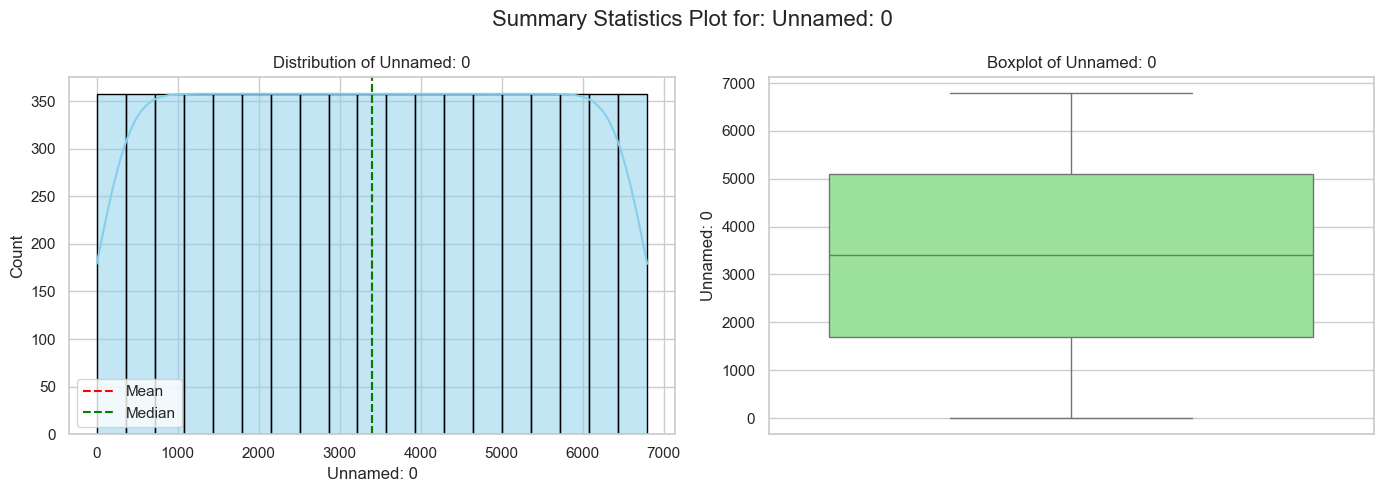

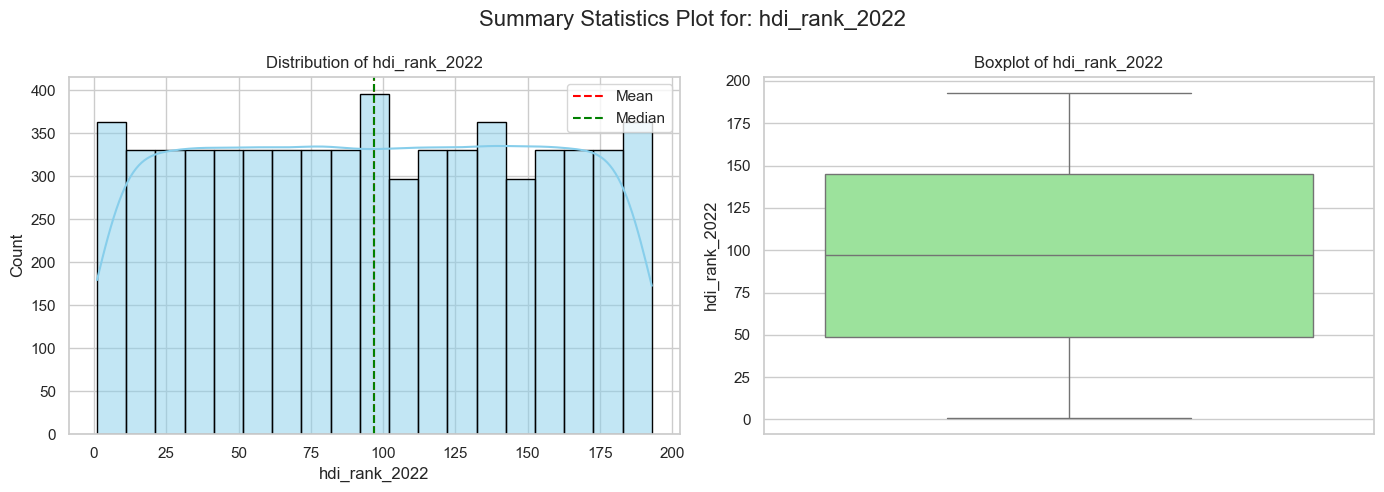

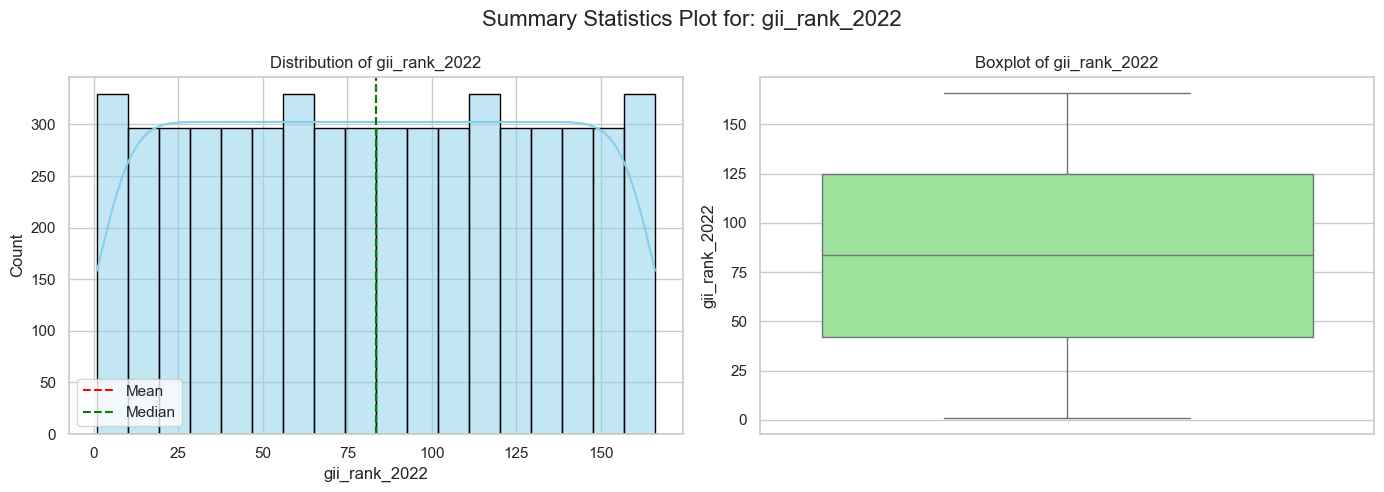

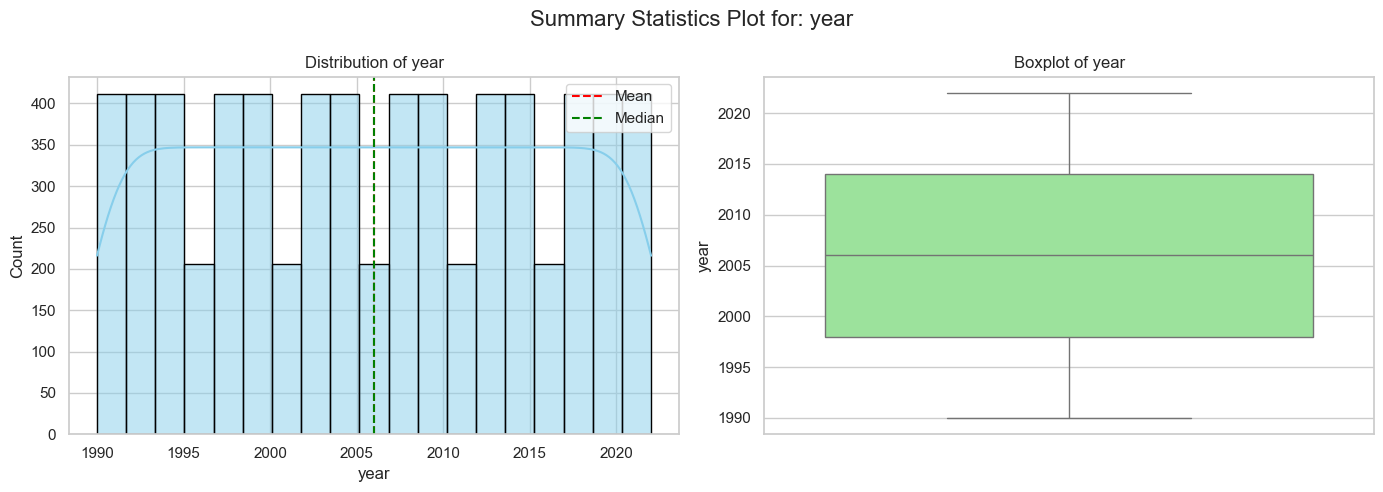

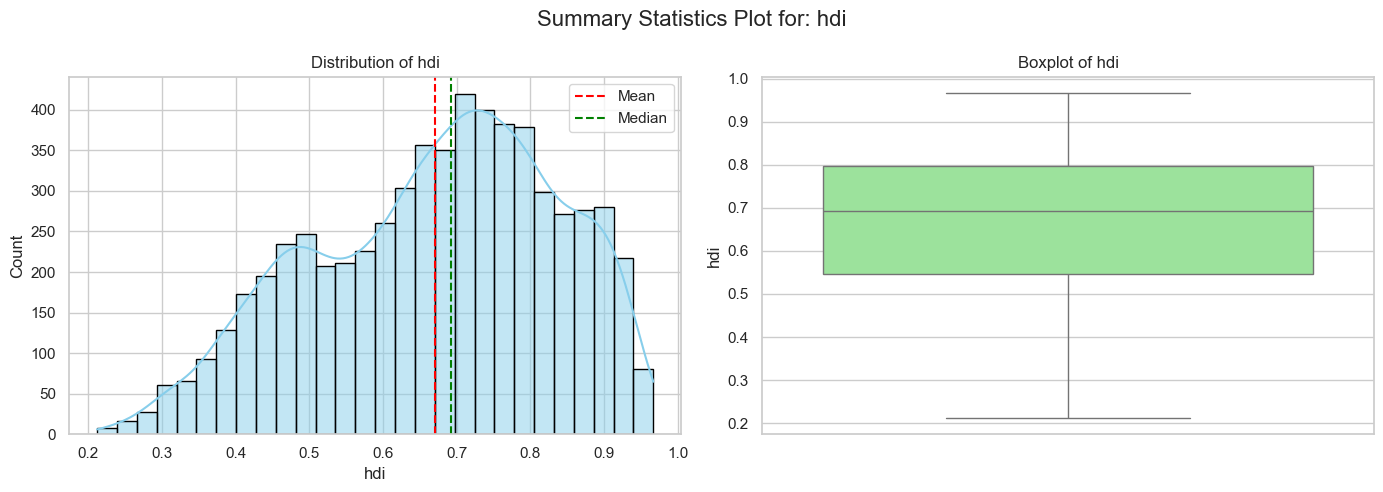

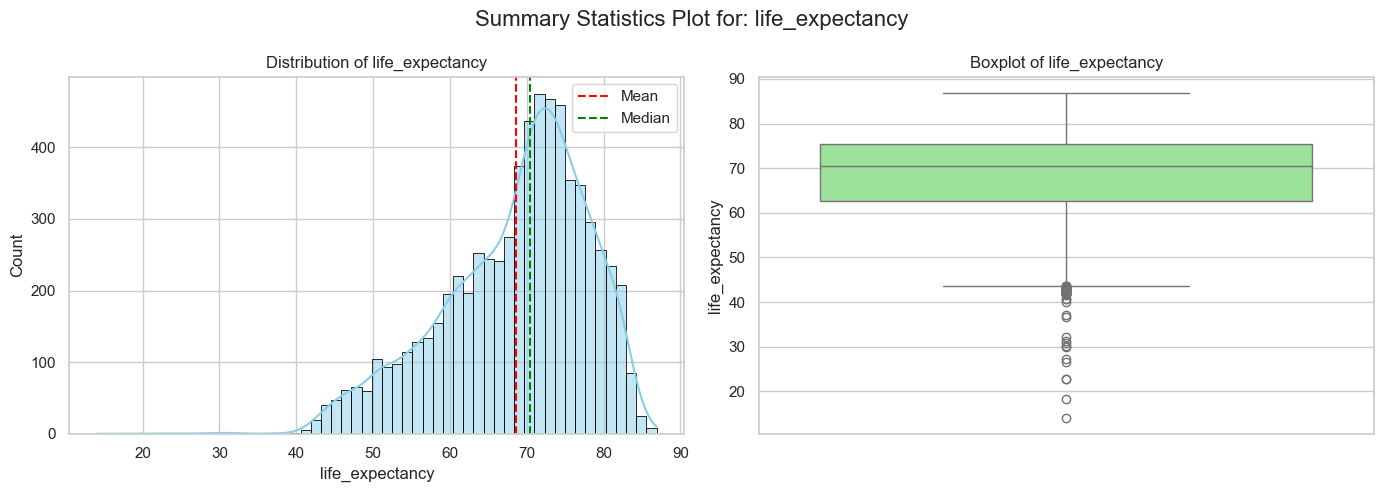

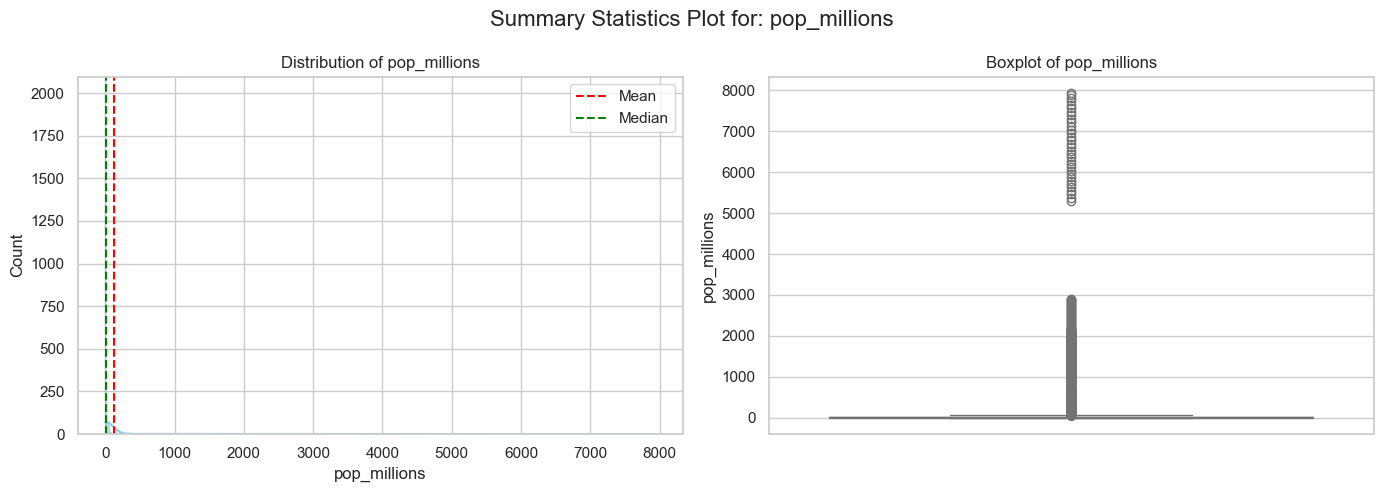

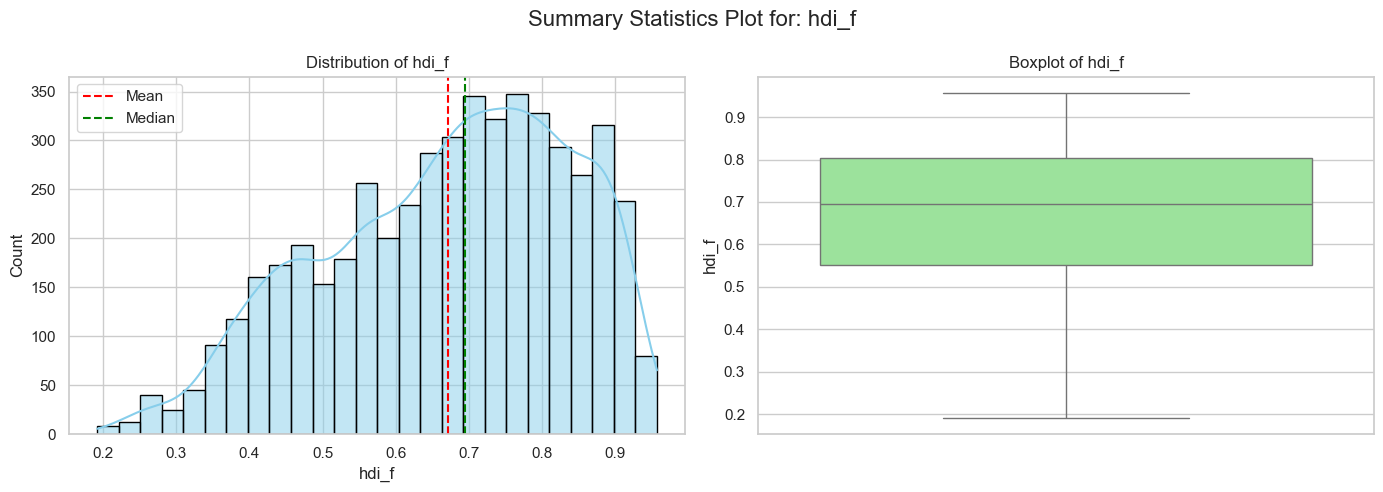

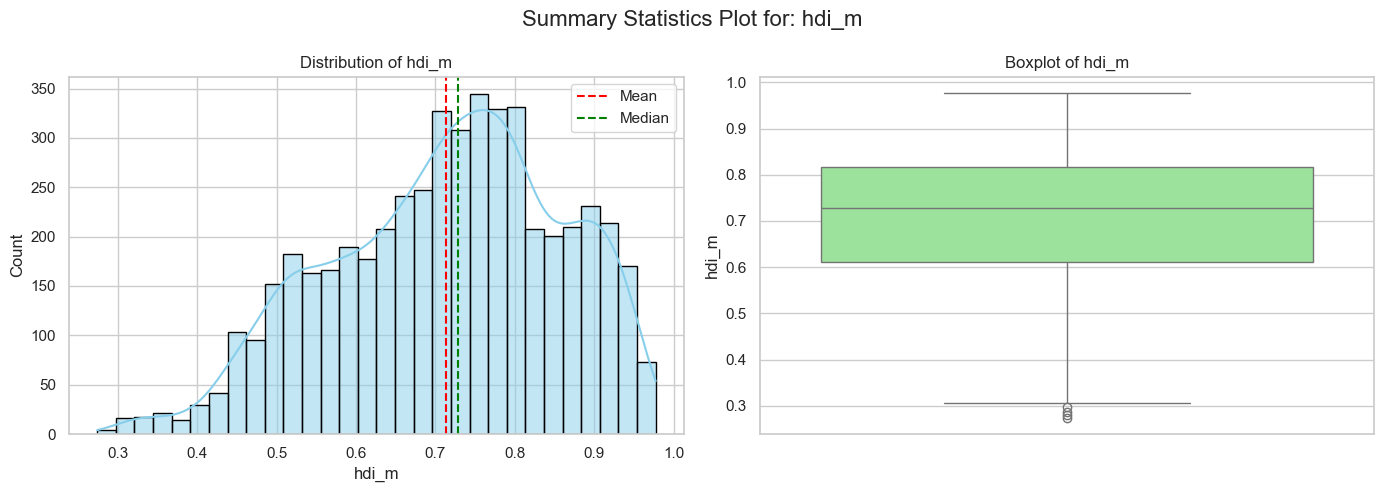

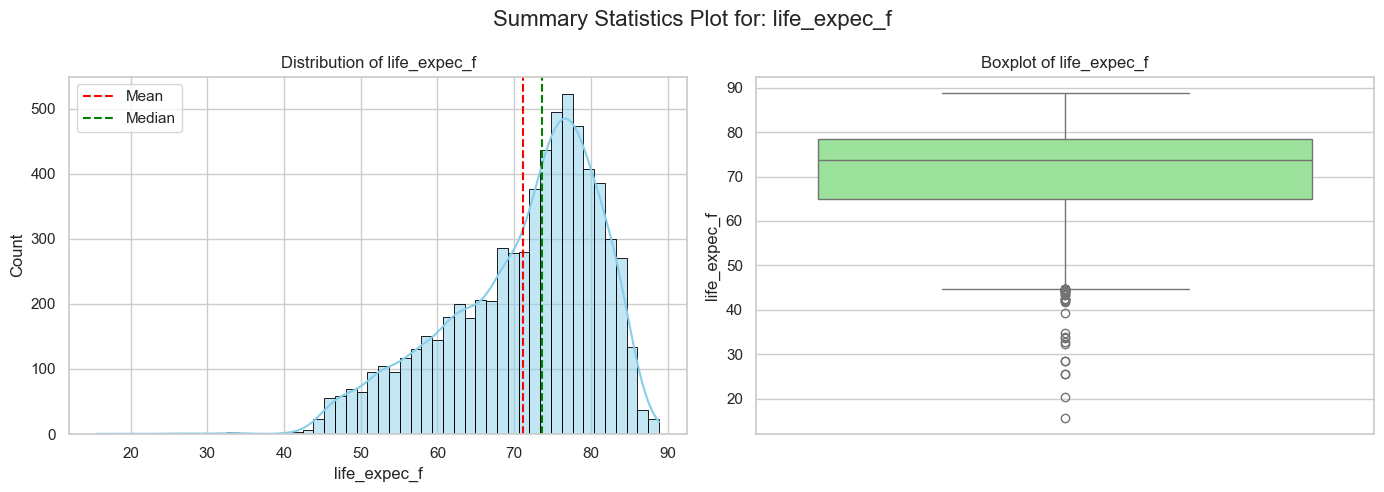

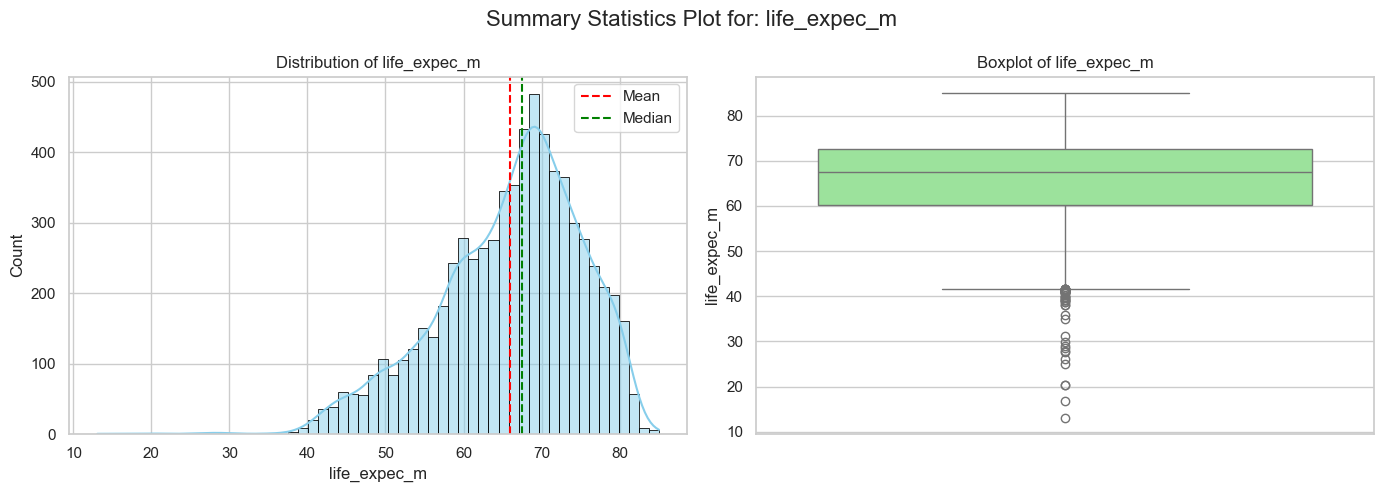

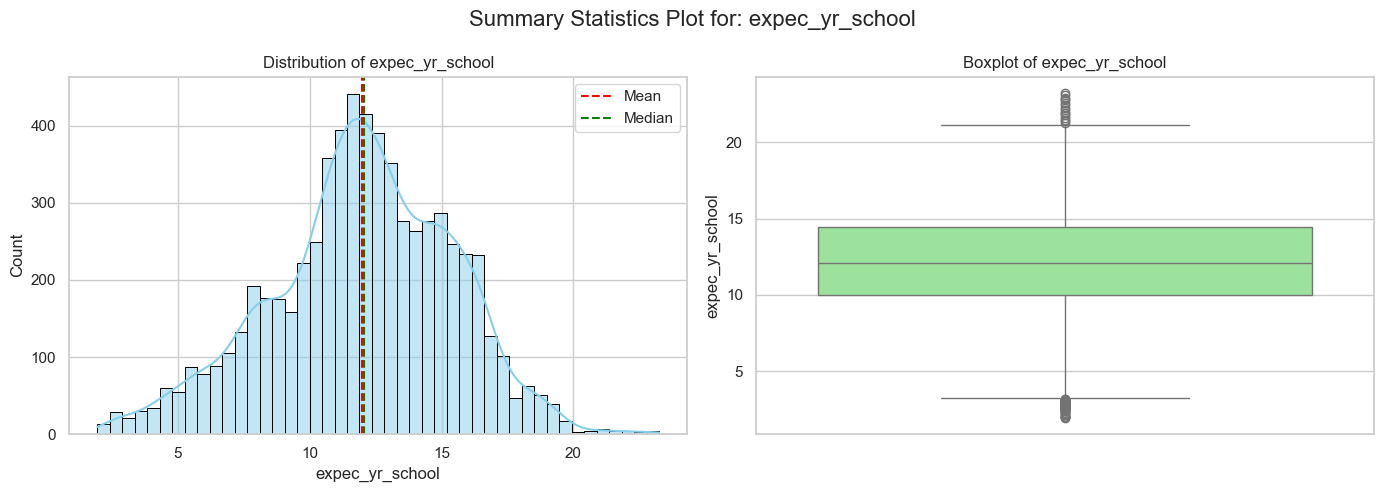

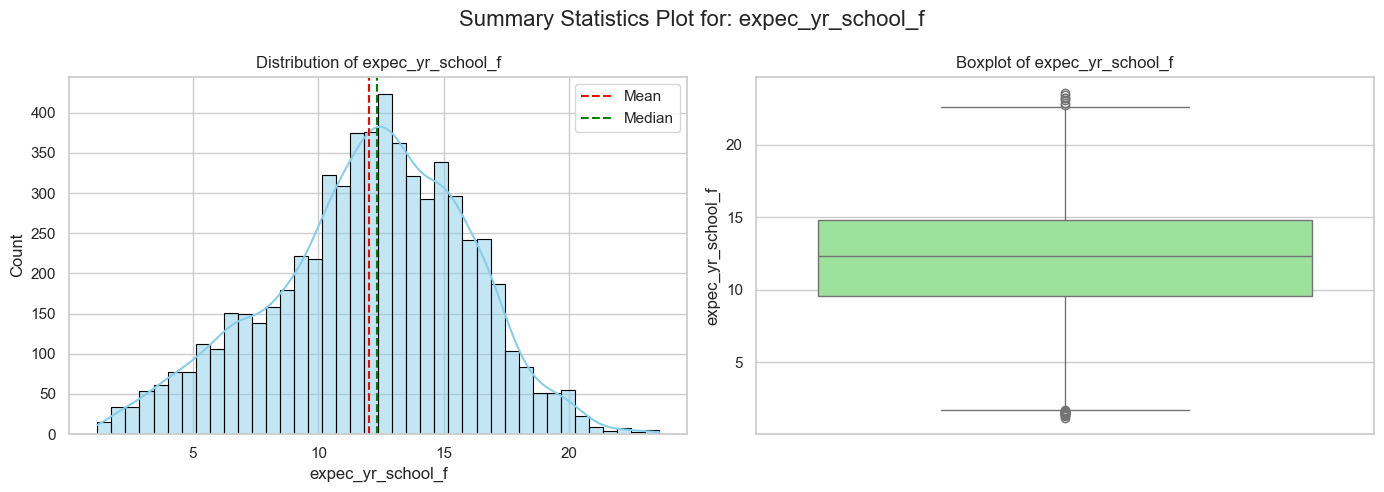

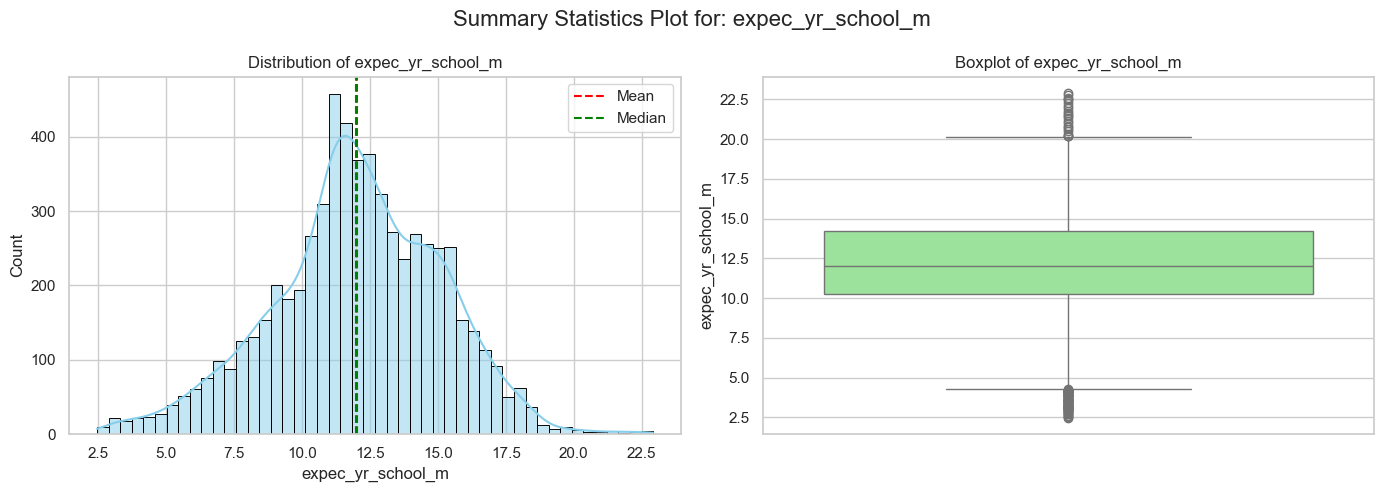

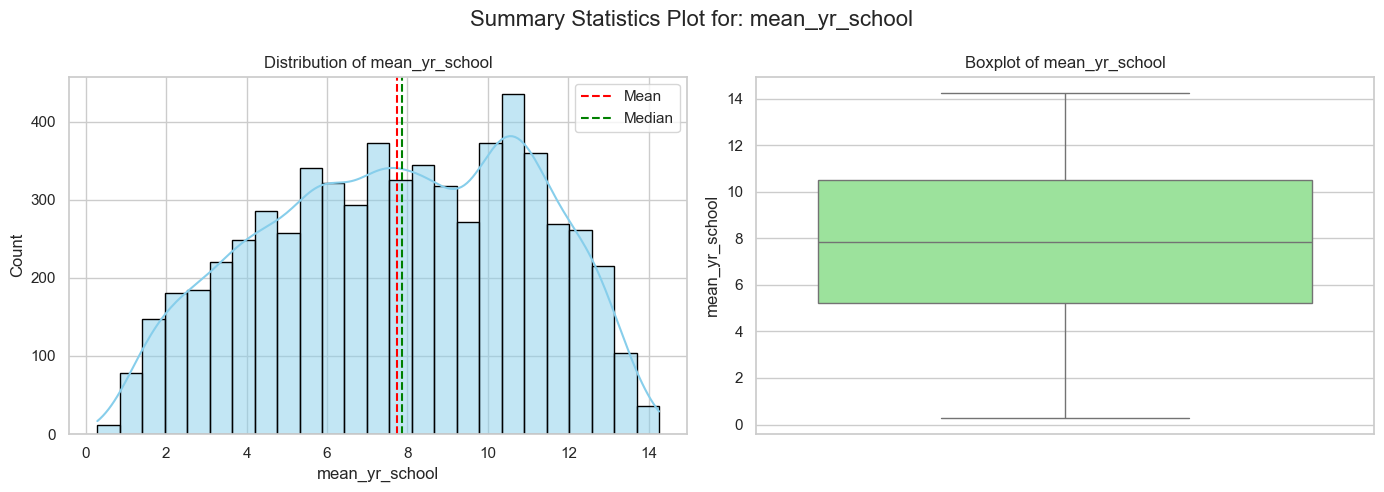

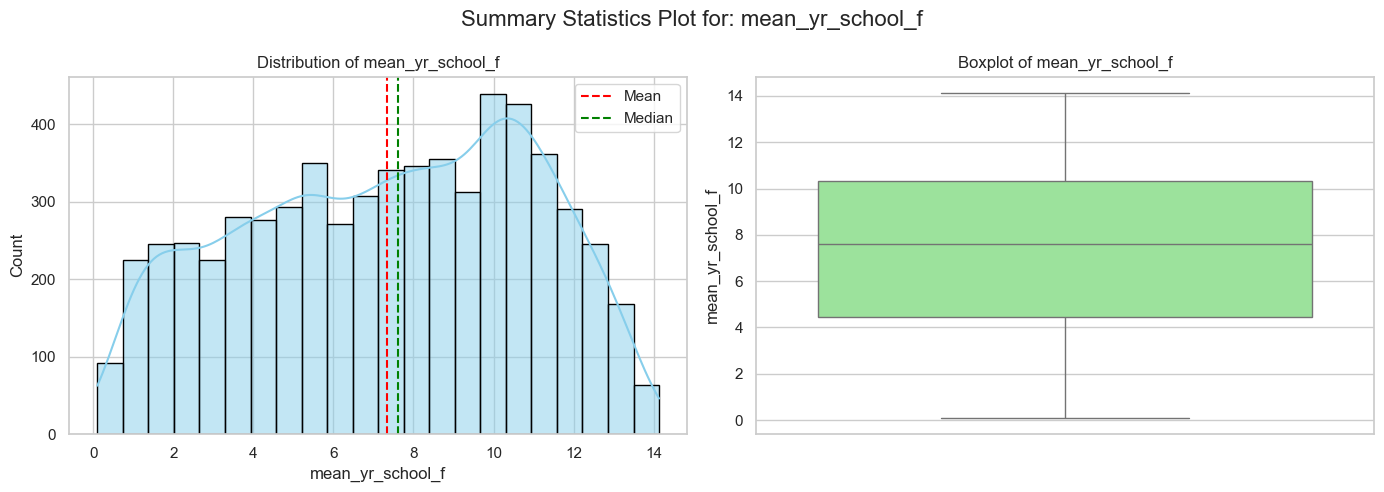

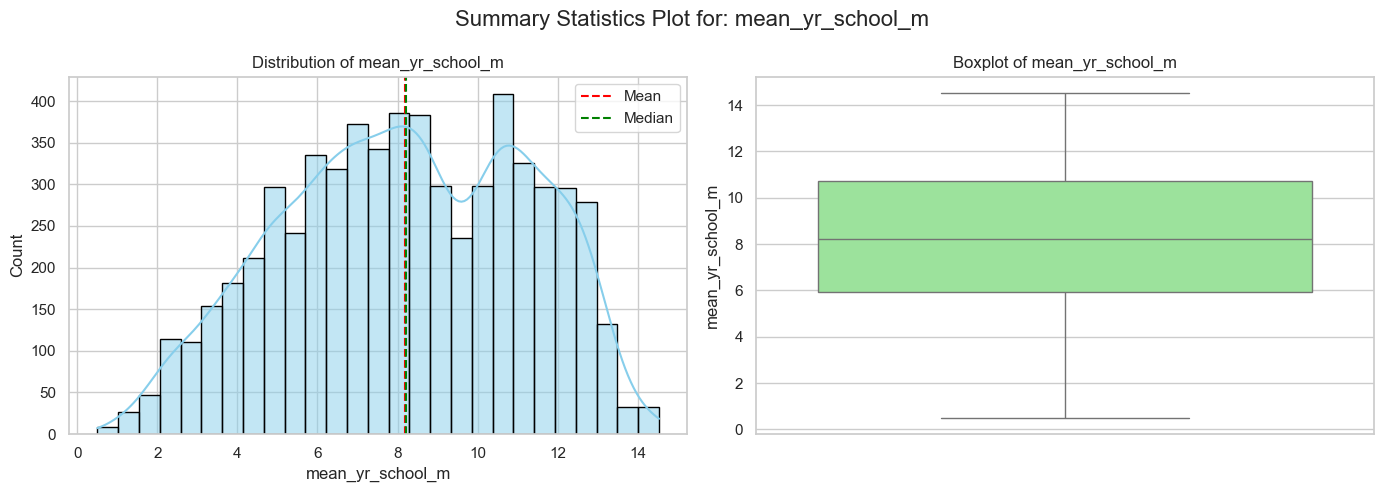

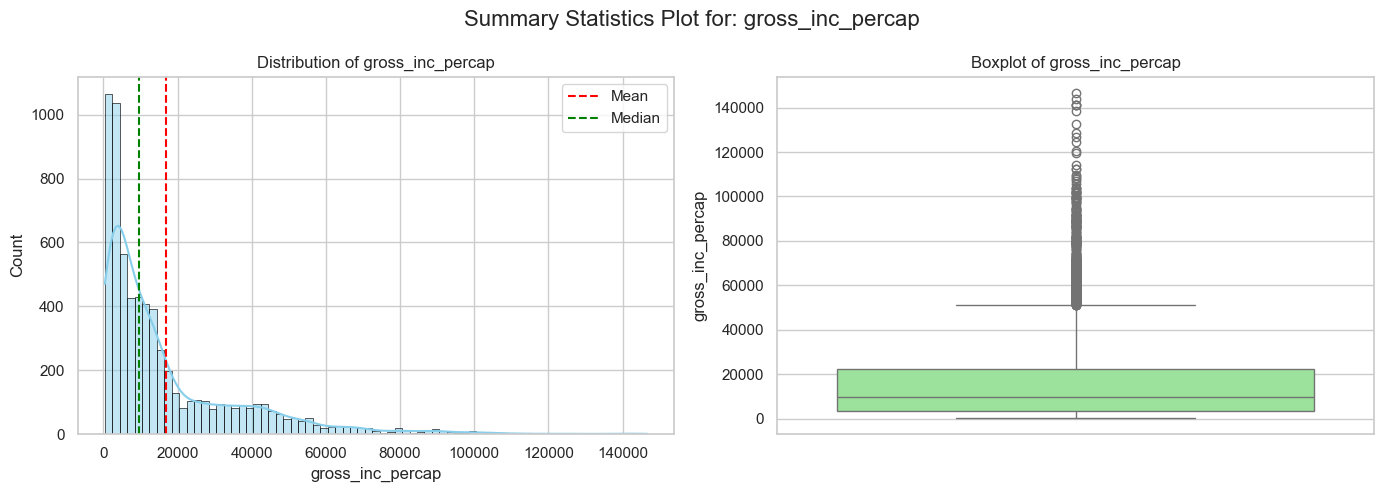

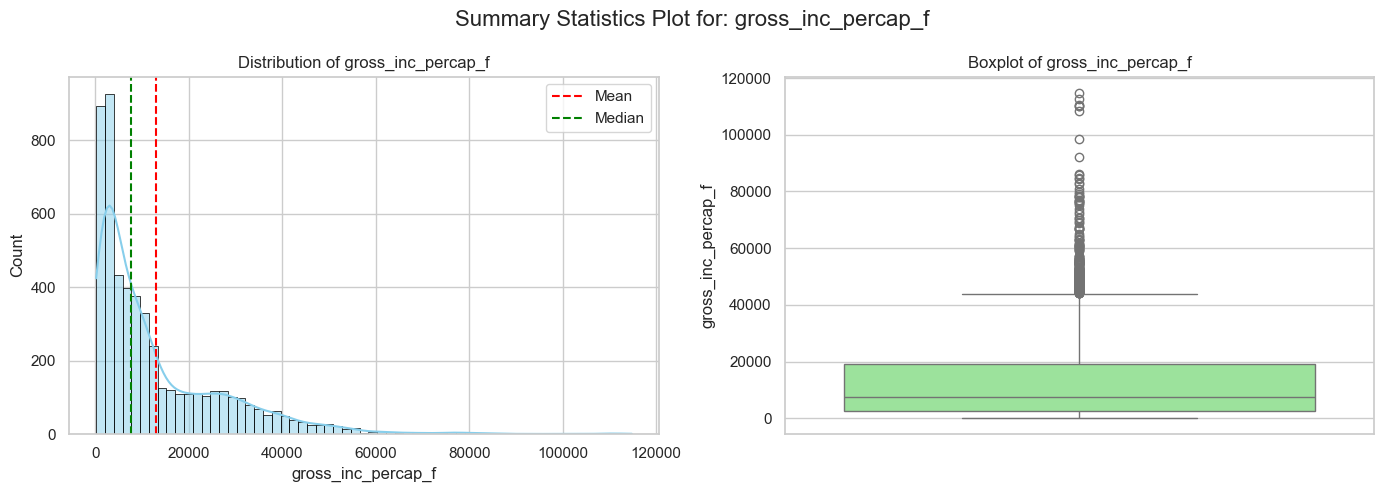

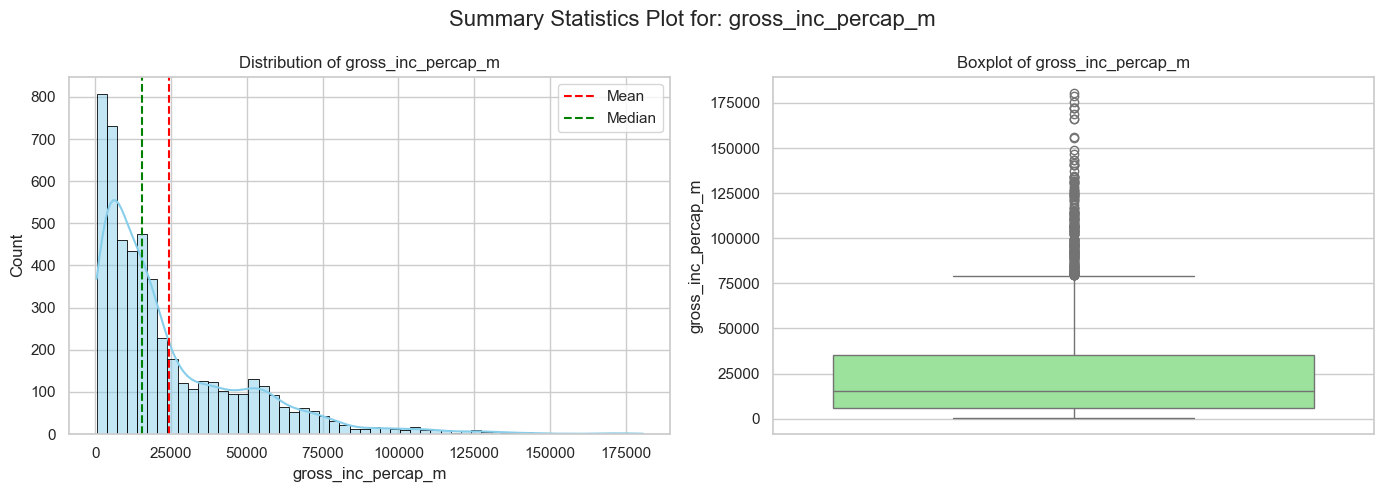

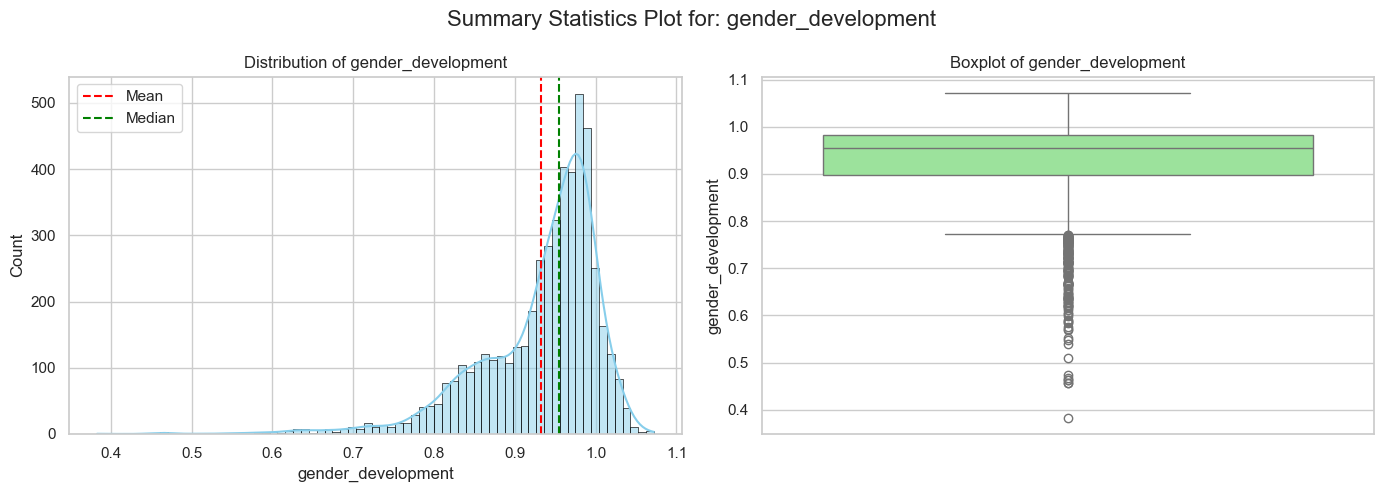

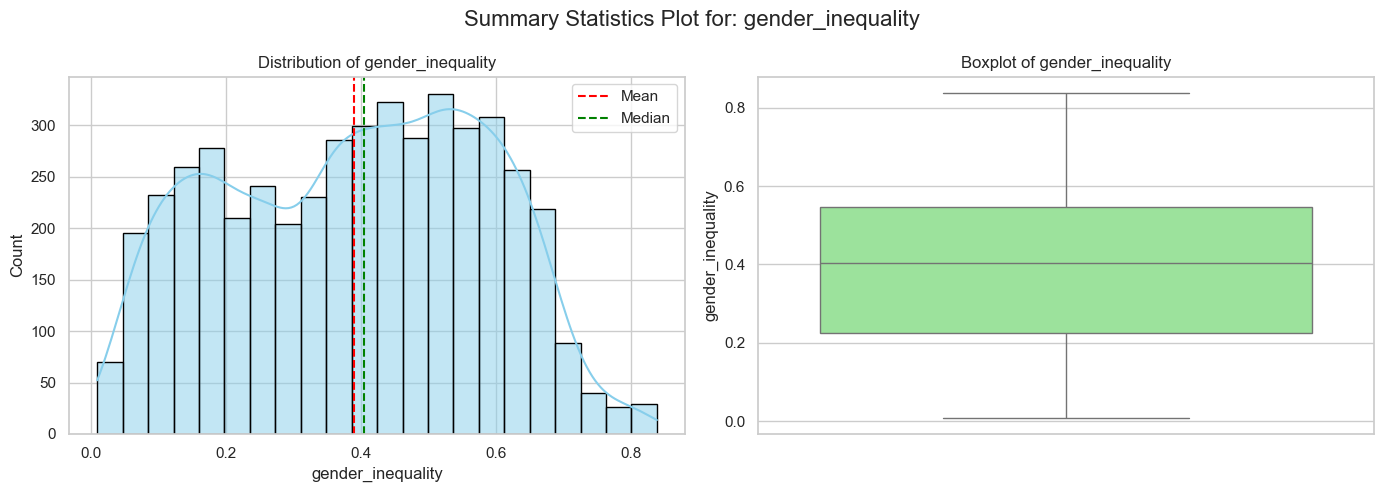

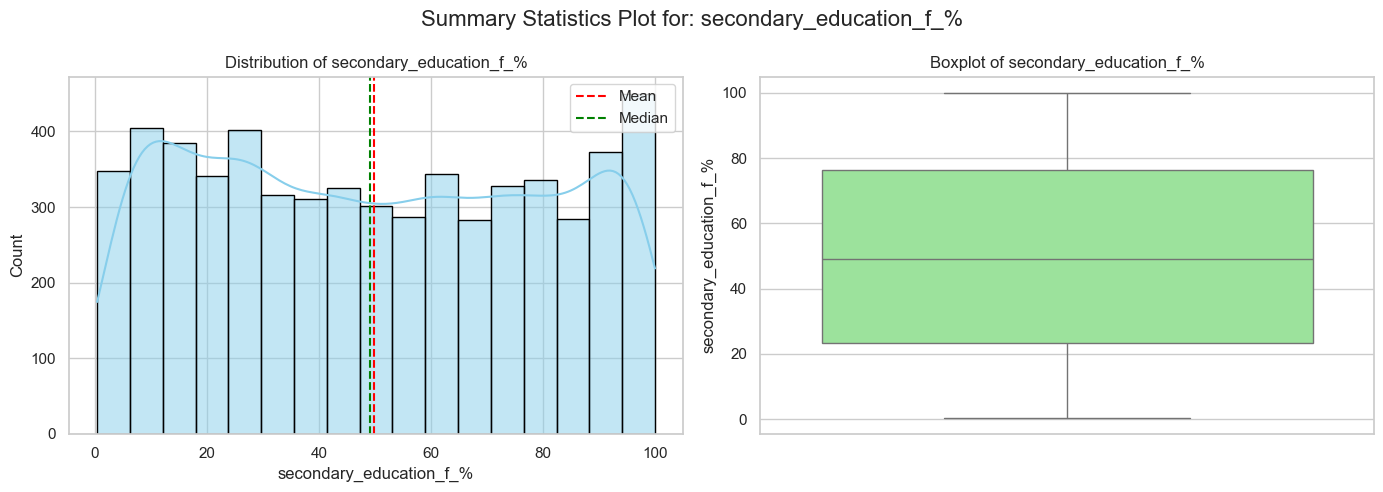

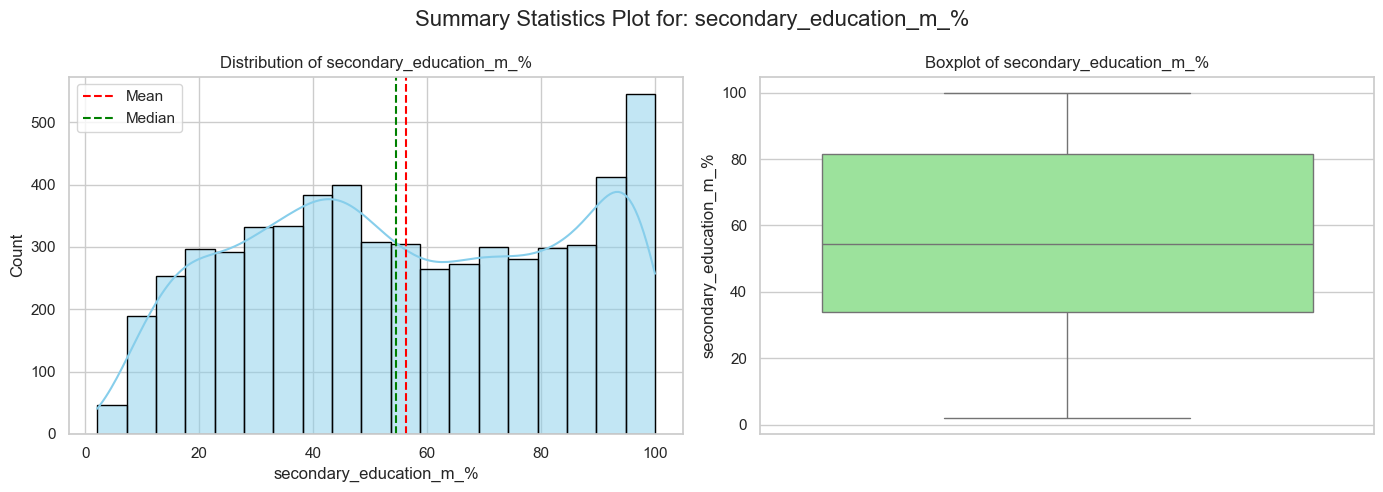

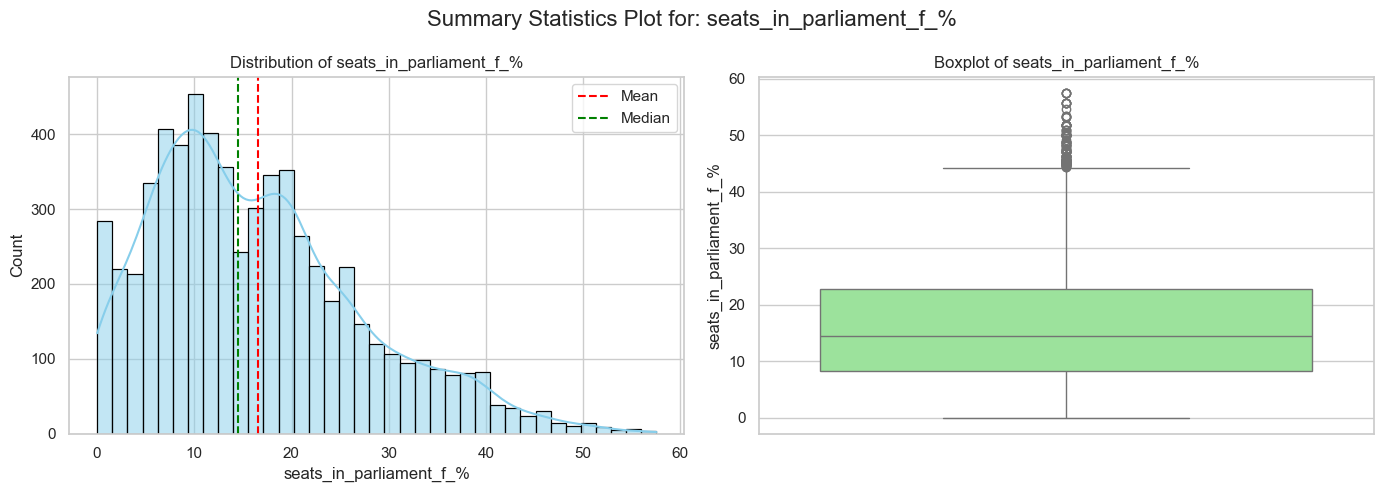

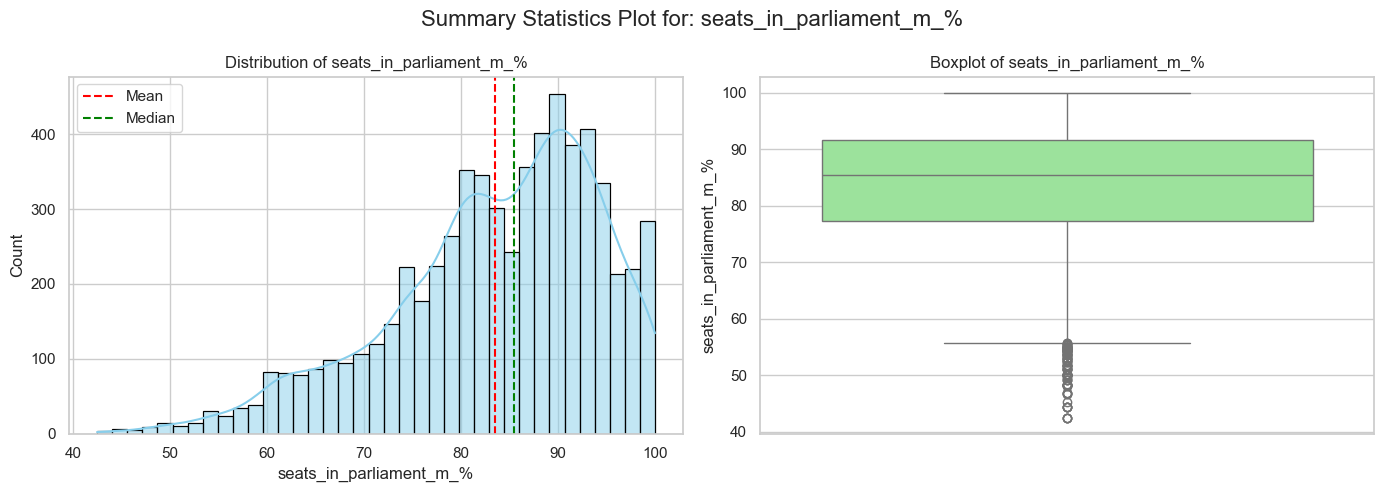

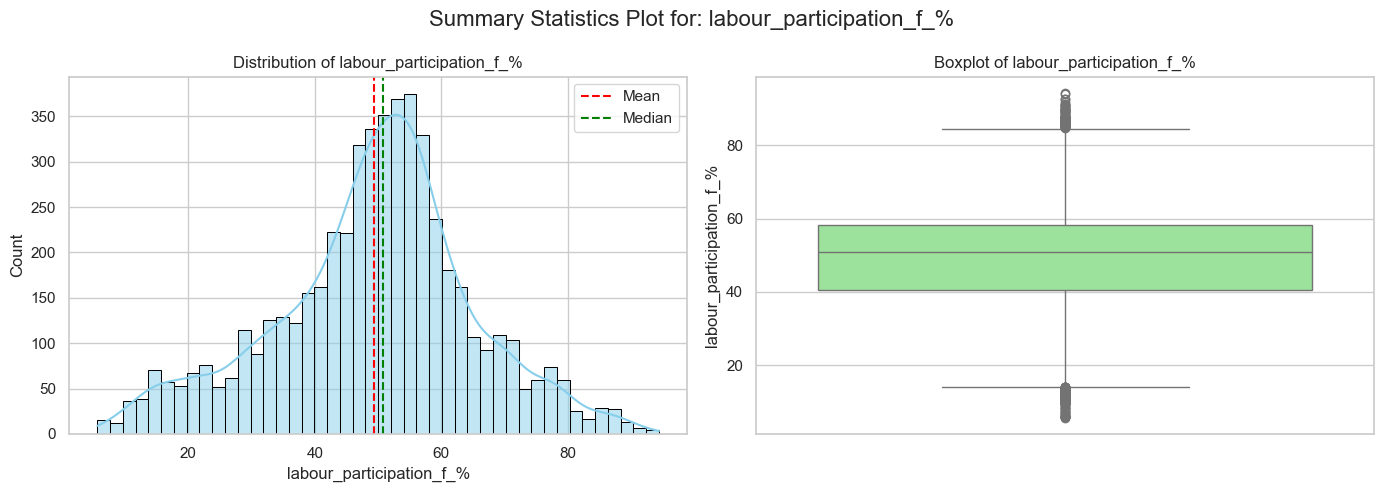

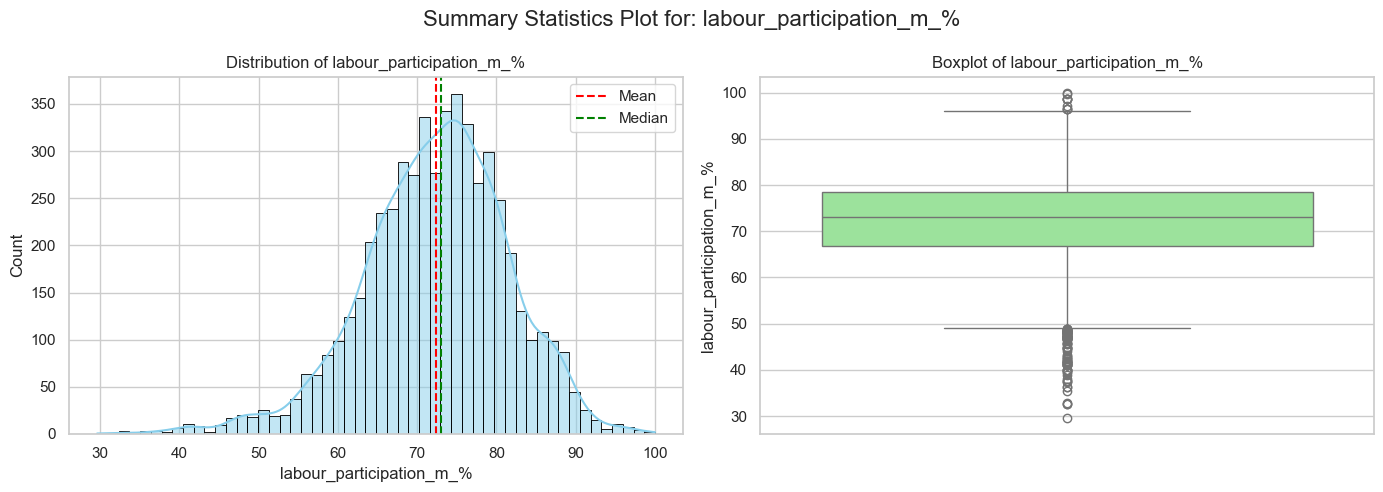

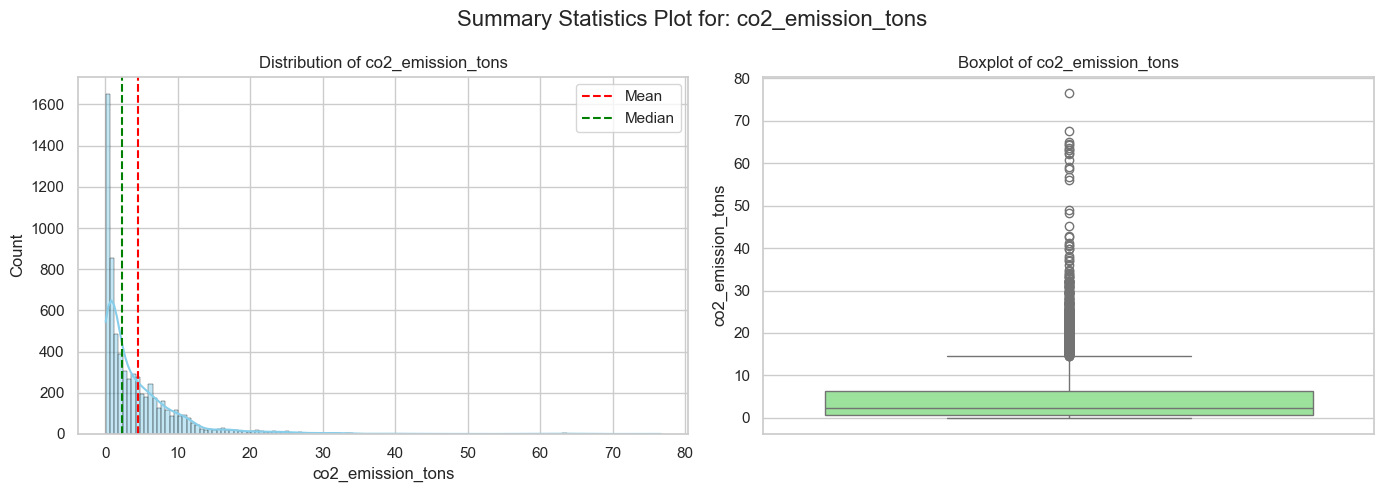

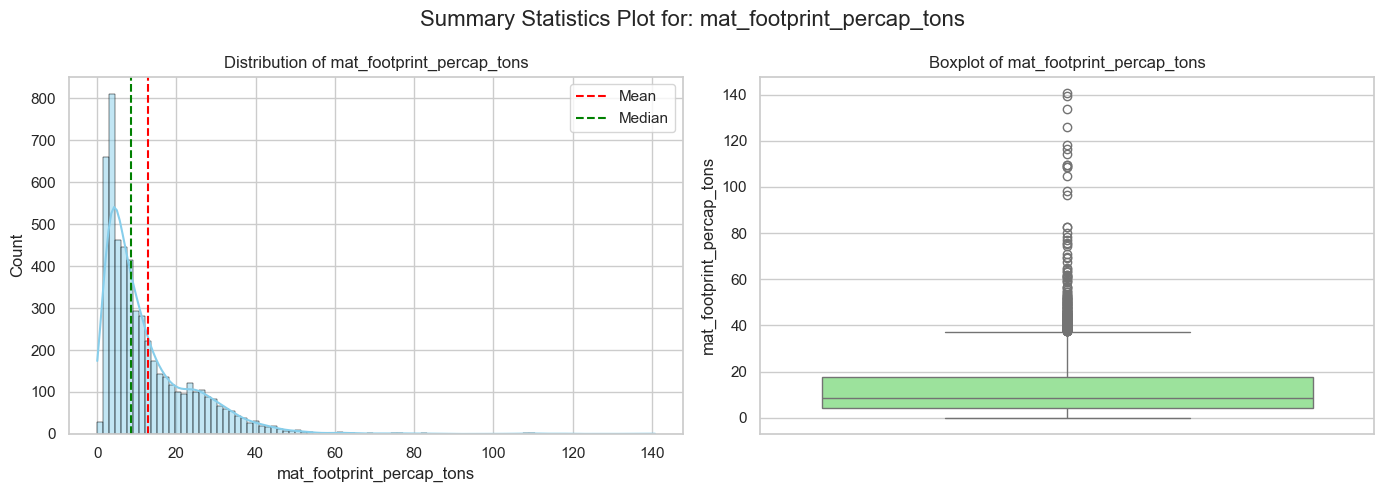

In [6]:
# Set plot style
sns.set(style="whitegrid")

# Identify numeric columns only
numeric_cols = data.select_dtypes(include='number').columns

# Create plots
for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram + KDE
    sns.histplot(data[col], kde=True, ax=axes[0], color='skyblue', edgecolor='black')
    axes[0].set_title(f'Distribution of {col}')
    axes[0].axvline(data[col].mean(), color='red', linestyle='--', label='Mean')
    axes[0].axvline(data[col].median(), color='green', linestyle='--', label='Median')
    axes[0].legend()

    # Boxplot
    sns.boxplot(y=data[col], ax=axes[1], color='lightgreen')
    axes[1].set_title(f'Boxplot of {col}')

    plt.suptitle(f'Summary Statistics Plot for: {col}', fontsize=16)
    plt.tight_layout()
    plt.show()

The following is a comprehensive interpretation of the visual distributions seen above:  
*	`co2_emission_tons`  
Right-skewed distribution with a few countries emitting substantially more CO₂. These are likely industrialized or oil-exporting nations. Highlights the disparity in carbon footprint.  
*	`gross_inc_percap`   
Right-skewed. Majority of countries have low to medium income per capita, while a few have extremely high values. Suggests economic inequality.  
*	`gross_inc_percap_f` & `gross_inc_percap_m`      
Both show similar skewness but with male income generally higher. Indicates prevalent gender income inequality in many countries.

*	`gender_development`  
Most countries cluster around high values (~1), indicating moderate to high gender development. A few outliers suggest persistent inequality in certain nations.
*	`gender_inequality`  
Right-skewed: many countries exhibit low inequality, but some have high scores, reflecting severe gender-based disparities in health, empowerment, and labor.
*	`secondary_education_f_%` & `secondary_education_m_%`  
Male access is generally higher. Some countries show large gender gaps, especially in lower development regions.
*	`seats_in_parliament_f_%`  
Strong left-skew, with most countries under 30% representation. Reflects global underrepresentation of women in politics.
*	`labour_participation_f_%` & `labour_participation_m_%`  
Male participation is consistently high and stable. Female participation varies greatly and is typically lower, revealing labor inequality.
*	`mat_footprint_percap_tons`  
Highly right-skewed. Reflects overconsumption in developed countries and lower material usage in low-income nations.
*	`hdi`, `hdi_f`, `hdi_m`  
Distributions are mostly bell-shaped, with females typically having slightly higher HDI in developed countries. Gender gaps widen in lower-income nations.
*	`life_expec_f` & `life_expec_m`  
Females consistently have higher life expectancy. Distribution is normal but shifted higher for women.
*	`expec_yr_school`, `expec_yr_school_f`, `expec_yr_school_m`  
Female values are lower in some regions, reflecting unequal access. Most countries average around 10–15 years, with some outliers.
*	`mean_yr_school`, `mean_yr_school_f`, `mean_yr_school_m`  
Patterns mirror expected years but with slightly lower values. Gender gap visible, especially in developing countries.

## 1.2 *Handling Missing Values*

In [7]:
print("Number of duplicated observation: ",data.duplicated().sum()) # check for duplicates


Number of duplicated observation:  0


In [8]:
data.head()

,Unnamed: 0,iso3,country,hdicode,hdi_rank_2022,gii_rank_2022,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,life_expec_m,expec_yr_school,expec_yr_school_f,expec_yr_school_m,mean_yr_school,mean_yr_school_f,mean_yr_school_m,gross_inc_percap,gross_inc_percap_f,gross_inc_percap_m,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
0,1,AFG,Afghanistan,Low,182.0,162.0,1990,0.284,45.967,10.694796,NaN,NaN,48.397,43.709,2.936460,2.117230,4.532768,0.871962,0.201659,1.493952,3115.670448,NaN,NaN,NaN,NaN,1.107733,7.899011,NaN,NaN,NaN,NaN,0.189279,2.1809
1,2,AFG,Afghanistan,Low,182.0,162.0,1991,0.292,46.663,10.745167,NaN,NaN,49.144,44.353,3.228456,2.246242,4.768261,0.915267,0.218944,1.578809,2817.304736,NaN,NaN,NaN,NaN,1.221396,8.137953,NaN,NaN,NaN,NaN,0.178155,2.5264
2,3,AFG,Afghanistan,Low,182.0,162.0,1992,0.299,47.596,12.057433,NaN,NaN,50.320,45.070,3.520452,2.383115,5.015989,0.958573,0.236229,1.663665,2474.681985,NaN,NaN,NaN,NaN,1.335059,8.376896,NaN,NaN,NaN,NaN,0.122920,2.6421
3,4,AFG,Afghanistan,Low,182.0,162.0,1993,0.307,51.466,14.003760,NaN,NaN,52.739,50.216,3.812448,2.528328,5.276587,1.001878,0.253514,1.748522,1723.019763,NaN,NaN,NaN,NaN,1.448722,8.615838,NaN,NaN,NaN,NaN,0.106179,2.3022
4,5,AFG,Afghanistan,Low,182.0,162.0,1994,0.300,51.495,15.455554,NaN,NaN,53.544,49.531,4.104445,2.682390,5.550723,1.045184,0.270800,1.833378,1202.010488,NaN,NaN,NaN,NaN,1.562385,8.854780,NaN,NaN,NaN,NaN,0.094063,1.8948


In [9]:
data.tail()

,Unnamed: 0,iso3,country,hdicode,hdi_rank_2022,gii_rank_2022,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,life_expec_m,expec_yr_school,expec_yr_school_f,expec_yr_school_m,mean_yr_school,mean_yr_school_f,mean_yr_school_m,gross_inc_percap,gross_inc_percap_f,gross_inc_percap_m,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
6793,6794,ZZK.WORLD,World,NaN,NaN,NaN,2018,0.735,72.816178,7649.567694,0.711839,0.754741,75.286179,70.443192,12.651182,12.694327,12.615530,8.483187,7.932751,9.047396,16431.28555,11735.92454,21256.93121,0.943,0.470,62.161959,69.593772,24.098697,75.901303,45.619782,73.702435,4.601230,12.444117
6794,6795,ZZK.WORLD,World,NaN,NaN,NaN,2019,0.739,73.012121,7730.660623,0.716428,0.757589,75.481761,70.637740,12.726141,12.803410,12.657070,8.574383,8.059405,9.121410,16713.67643,11956.15153,21496.69906,0.946,0.467,62.953836,70.542738,24.670774,75.329226,46.252332,73.746082,4.589431,11.864860
6795,6796,ZZK.WORLD,World,NaN,NaN,NaN,2020,0.736,72.257355,7806.602793,0.715597,0.753310,74.857415,69.800223,12.860674,12.937502,12.795625,8.686374,8.246301,9.155630,16015.84583,11539.26248,20521.06848,0.950,0.463,64.385236,71.331807,25.370844,74.629156,45.457446,72.687775,4.336829,12.178989
6796,6797,ZZK.WORLD,World,NaN,NaN,NaN,2021,0.735,71.365524,7874.877719,0.714806,0.751553,73.978883,68.912841,12.911840,12.998299,12.833189,8.682265,8.250592,9.140639,16837.84180,12145.11957,21566.00759,0.951,0.463,64.325131,71.182639,25.913010,74.086990,46.169728,73.349464,4.520335,12.456034
6797,6798,ZZK.WORLD,World,NaN,NaN,NaN,2022,0.739,72.004070,7940.608797,0.719488,0.756395,74.532307,69.599363,12.989766,13.082218,12.907841,8.661598,8.231362,9.118253,17254.43404,12515.51810,22034.76633,0.951,0.462,64.118558,70.967411,26.184549,73.815451,46.799926,73.880522,4.497895,12.470560


* `country` column has a value that has no `hdicode`. We need to detect is there any value like *World*.

In [10]:
data[data.hdicode.isna()]["country"].unique().tolist()

["Korea (Democratic People's Rep. of)",
 'Monaco',
 'Very high human development',
 'High human development',
 'Medium human development',
 'Low human development',
 'Arab States',
 'East Asia and the Pacific',
 'Europe and Central Asia',
 'Latin America and the Caribbean',
 'South Asia',
 'Sub-Saharan Africa',
 'World']

* All values of country if hdicode is missing is in the list. The observations belong to a specific region or human development. We need to remove those records to have proper insights about the countries in the analysis.

In [ ]:
removed_country_list = [
 'Very high human development',
 'High human development',
 'Medium human development',
 'Low human development',
 'Arab States',
 'East Asia and the Pacific',
 'Europe and Central Asia',
 'Latin America and the Caribbean',
 'South Asia',
 'Sub-Saharan Africa',
 'World']
data_not_country = data[data["country"].isin(removed_country_list)] #those records may be used for other analysis
data_cleaned= data[~data["country"].isin(removed_country_list)] 

hdi_miss=data_cleaned[data_cleaned.hdicode.isna()]
hdi_miss.isnull().sum().sum()/(hdi_miss.shape[0]*hdi_miss.shape[1])*100
print("Percentage of the missing values in Monaco and North Korea: ", round(hdi_miss.isnull().sum().sum()/(hdi_miss.shape[0]*hdi_miss.shape[1])*100,2),"%")

Percentage of the missing values in Monaco and North Korea:  62.53 %


* After removing those records we have missing values of hdicode for **North Korea** and **Monaco**. But those two countries have too much missing values in the records. Hence, droping these countries is not bad preference for further analysis.

In [14]:
removed_country_list= removed_country_list + ["Korea (Democratic People's Rep. of)",
 'Monaco']

data_cleaned= data_cleaned[~data_cleaned["country"].isin(removed_country_list)] 

In [ ]:
missing_each = data_cleaned.isnull().sum()
missing_each_percent = data_cleaned.isnull().mean().round(2)*100
missing_sum = data_cleaned.isnull().sum().sum()
missing_percent= round(missing_sum/(data_cleaned.shape[0]*data_cleaned.shape[1]),4)*100
fully_data= data_cleaned.dropna().shape[0]
print("percentage of the missing values by column:", "\n",missing_each_percent,"\n","\n","Total number of missing values: ", missing_sum,"\n","Percentage of the missing values: {}% ".format(missing_percent),
     "\n","Fully entered data(Percentage): ",fully_data,"({}%)".format(round(fully_data/data_cleaned.shape[0]*100)))

percentage of the missing values by column: 
 Unnamed: 0                    0.0
iso3                          0.0
country                       0.0
hdicode                       0.0
hdi_rank_2022                 0.0
gii_rank_2022                14.0
year                          0.0
hdi                           9.0
life_expectancy               0.0
pop_millions                  0.0
hdi_f                        26.0
hdi_m                        26.0
life_expec_f                  0.0
life_expec_m                  0.0
expec_yr_school               3.0
expec_yr_school_f             8.0
expec_yr_school_m             8.0
mean_yr_school                8.0
mean_yr_school_f              9.0
mean_yr_school_m              9.0
gross_inc_percap              1.0
gross_inc_percap_f           22.0
gross_inc_percap_m           22.0
gender_development           26.0
gender_inequality            31.0
secondary_education_f_%      14.0
secondary_education_m_%      14.0
seats_in_parliament_f_%       8.0
se

* at least 69% of the values in each of the variables are present. Hence, trying to fill the missing values is better option than drop any features. 


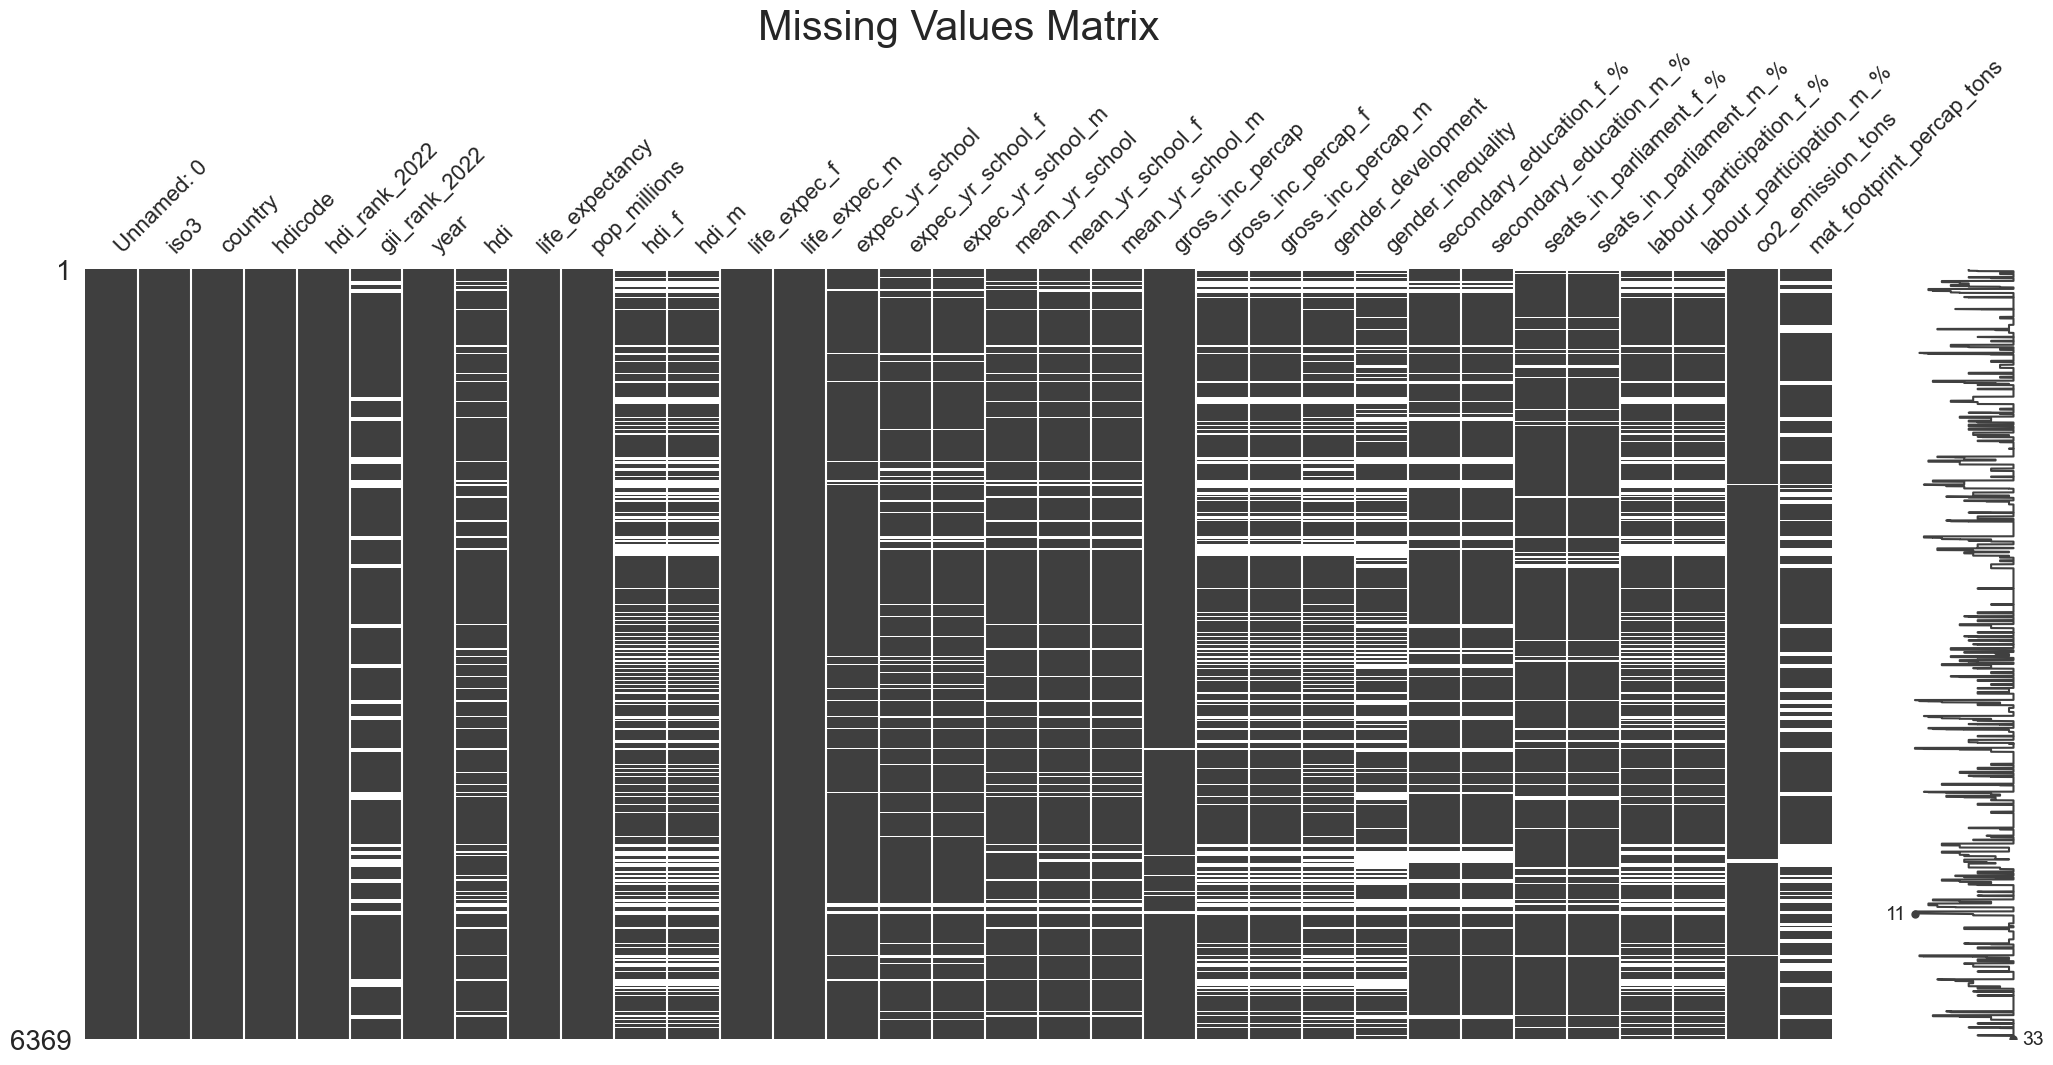

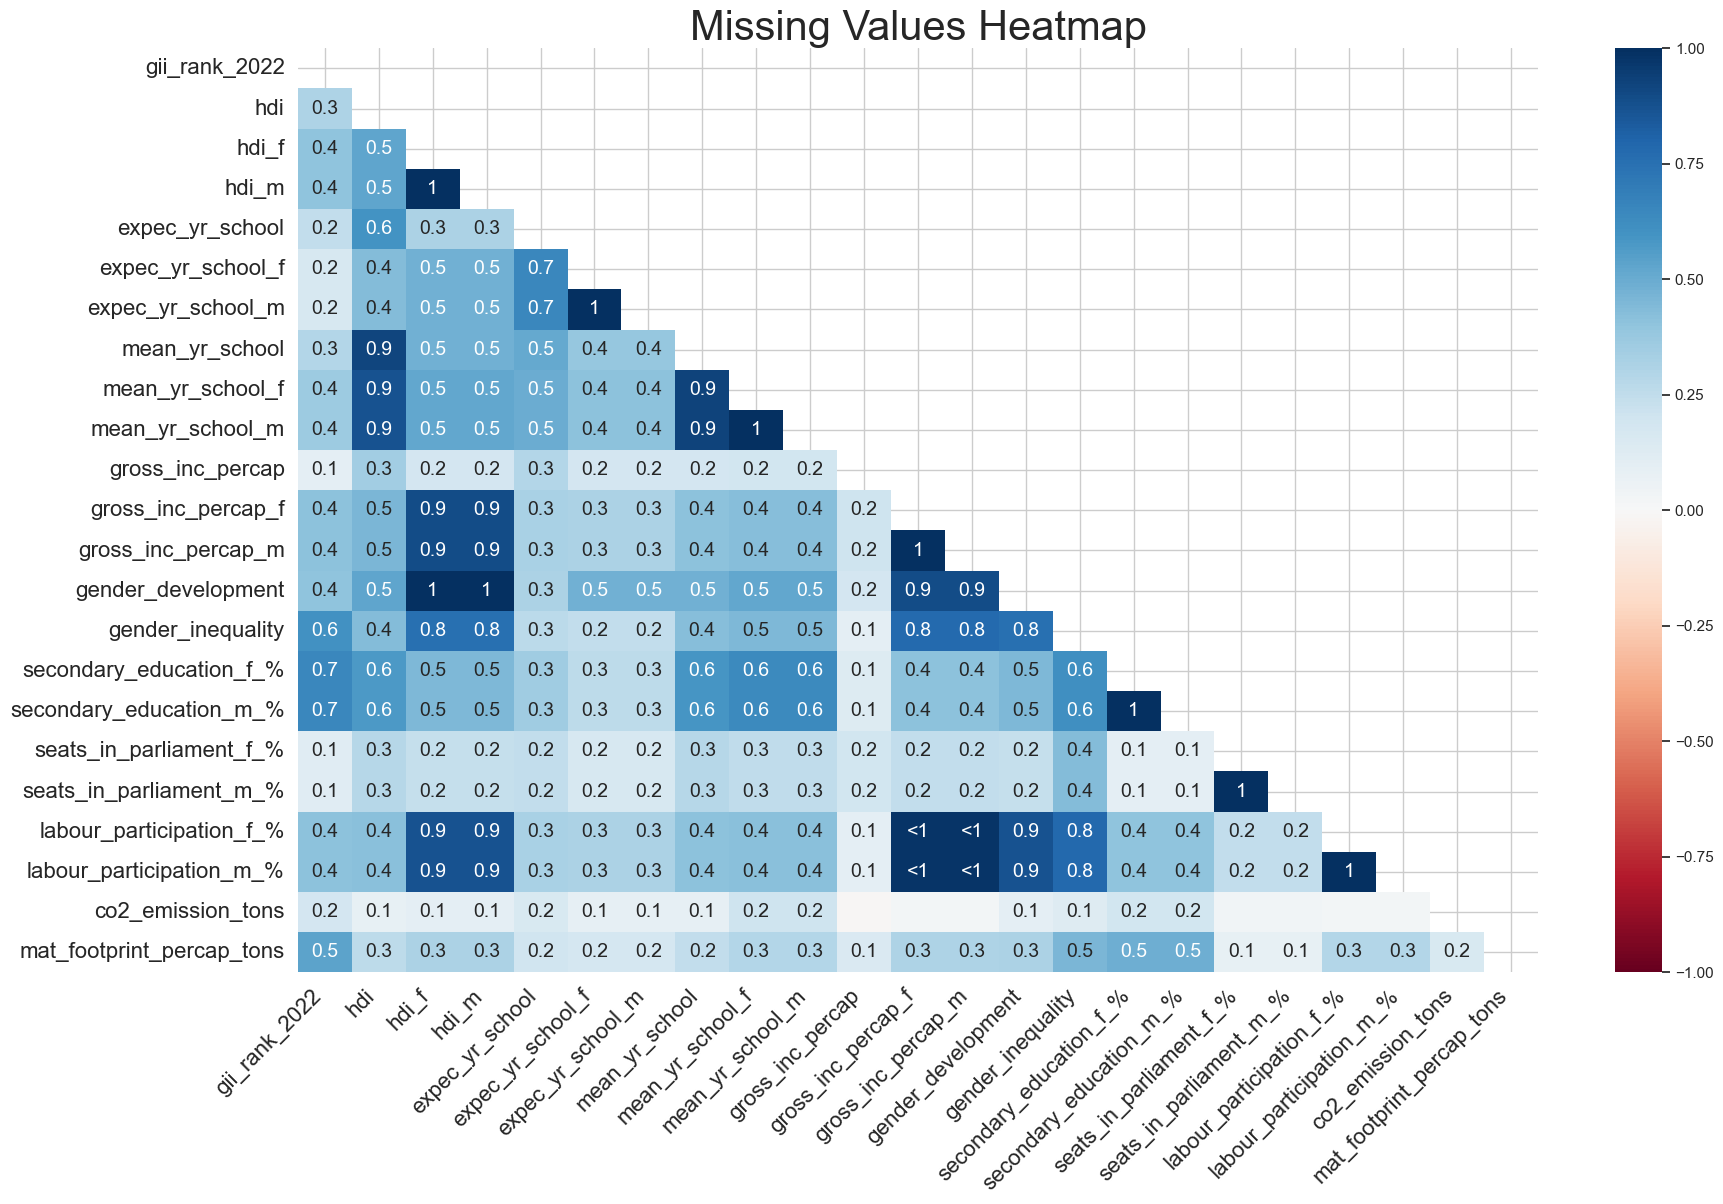

In [ ]:
msno.matrix(data_cleaned)
plt.title('Missing Values Matrix', fontsize=30)
msno.heatmap(data_cleaned)
plt.title('Missing Values Heatmap', fontsize=30)
plt.show()

missing values heatmap shows us the the heat map of the rows which only has missing value or values.

interpration:
- -1 means if one variable is present the other one is absolutely missing.
- 0 means there is no effect the variable on another about peresence.
- 1 means if one variable is present the other one is absolutely present.

We can see some of the variables highly correlated about missingnes.

Text(0.5, 1.0, 'Correlation Heatmap')

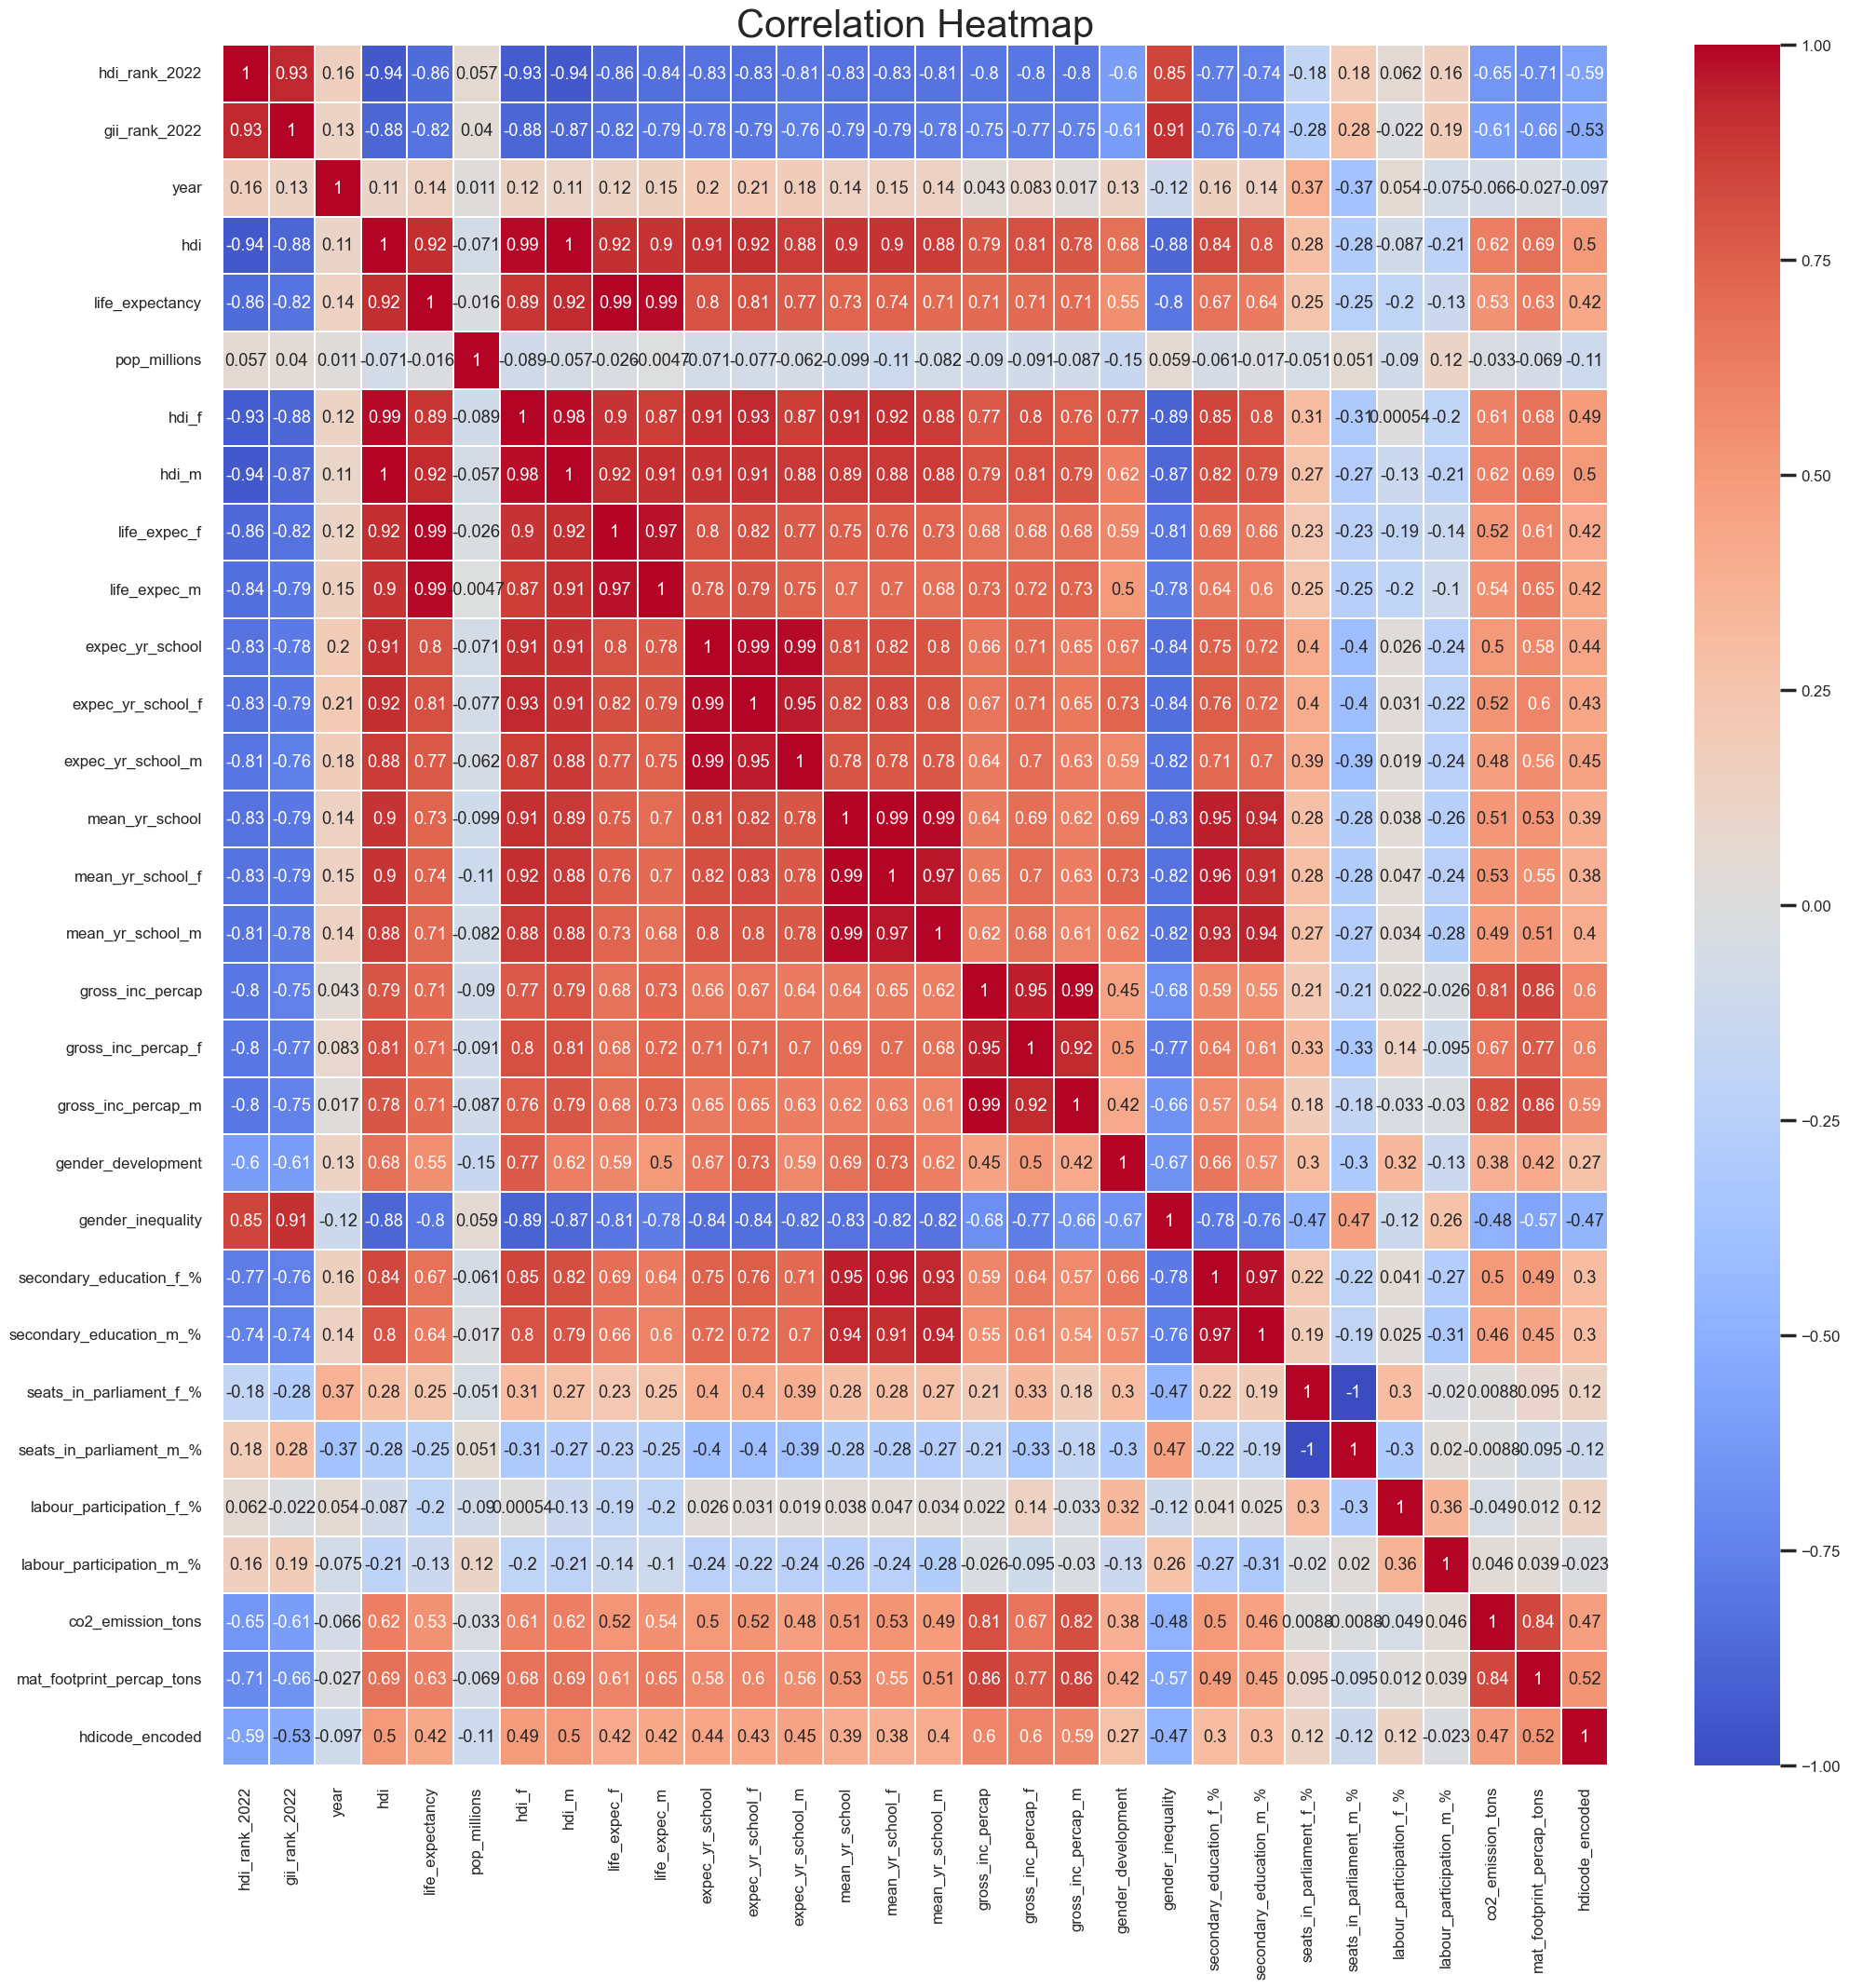

In [17]:
# encode categorical variables or drop them
le = LabelEncoder()
data_cleaned["hdicode_encoded"] = le.fit_transform(data_cleaned["hdicode"])
data_numeric = data_cleaned.drop(columns=["iso3","country","hdicode","Unnamed: 0"])

#drop missing values to see the correlation between the variables
data_numeric = data_numeric.dropna()

sns.set_theme(context="poster",font_scale=0.55)
sns.diverging_palette(220, 20, as_cmap=True)
plt.figure(figsize=(24,24))
sns.heatmap(data_numeric.corr(),annot=True,linewidths=0.2,cmap="coolwarm")
plt.title("Correlation Heatmap", fontsize=30)

* Some of the variables highly corelate linearly. For example, mean year in school and expected year in school, gross income per capita and life expectancy are highly corelate for men and women.

* Apply one hot encode to the country column to use for the missing values in the handling missing value part. 

In [ ]:
# Ensure 'country' is categorical
data_cleaned["country"] = data_cleaned["country"].astype(str)

# Initialize OneHotEncoder
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False) 

# Apply one-hot encoding to 'country'
encoded_countries = pd.DataFrame(encoder.fit_transform(data_cleaned[["country"]]))

# Add column names
encoded_countries.columns = encoder.get_feature_names_out(["country"])

# Reset index to align with original dataset
encoded_countries.index = data_cleaned.index

# Copy original dataset
data_filled = data_cleaned.copy()

# Ensure index alignment before merging
data_filled = data_filled.reset_index(drop=True)
encoded_countries = encoded_countries.reset_index(drop=True)

# Merge encoded data with original dataset
data_filled = pd.concat([data_filled, encoded_countries], axis=1)


#### Missing Data Summary and Imputation Strategies

| Variable                         | Missing % | Missingness Mechanism | Imputation Method             | Justification |
|----------------------------------|-----------|------------------------|-------------------------------|---------------|
| `gii_rank_2022`                  | 14.0%     | MAR                    | Regression / MICE             | Depends on gender indicators like inequality. |
| `hdi`                            | 9.0%      | MAR                    | Regression / MICE             | Predictable from life expectancy, education, income. |
| `hdi_f`                          | 26.0%     | MNAR                   | MICE / Group Median           | Gender-specific; often unreported in some regions. |
| `hdi_m`                          | 26.0%     | MNAR                   | MICE / Group Median           | Same reason as `hdi_f`. |
| `expec_yr_school`               | 3.0%      | MAR                    | Mean / Regression             | Small missingness |
| `expec_yr_school_f`             | 8.0%      | MAR                    | MICE / Regression             | Gendered version; infer from overall and male values. |
| `expec_yr_school_m`             | 8.0%      | MAR                    | MICE / Regression             | Same as above. |
| `mean_yr_school`                | 8.0%      | MAR                    | Regression / KNN              | Related to education and economic vars. |
| `mean_yr_school_f`              | 9.0%      | MAR                    | MICE / Regression             | Gendered, predictable via similar countries. |
| `mean_yr_school_m`              | 9.0%      | MAR                    | MICE / Regression             | Same as above. |
| `gross_inc_percap`              | 1.0%      | MCAR                   | Median / Regression           | Very small missingness |
| `gross_inc_percap_f`            | 22.0%     | MNAR                   | MICE / Group Median           | Missing in countries not tracking female income. |
| `gross_inc_percap_m`            | 22.0%     | MNAR                   | MICE / Group Median           | Same as above. |
| `gender_development`            | 26.0%     | MAR/MNAR               | MICE                          | Composite indicator; calculable if others are imputed. |
| `gender_inequality`             | 31.0%     | MNAR                   | Flag /  | High missingness; possibly unavailable in some countries. |
| `secondary_education_f_%`       | 14.0%     | MAR                    | Regression / MICE             | Imputable from male %, mean years of schooling. |
| `secondary_education_m_%`       | 14.0%     | MAR                    | Regression / MICE             | Same as above. |
| `seats_in_parliament_f_%`       | 8.0%      | MAR                    | Mean (regional)   | Can use regional norms for imputation. |
| `seats_in_parliament_m_%`       | 8.0%      | MAR                    | Derive from `100 - f %`       | Fully determined by female share. |
| `labour_participation_f_%`      | 22.0%     | MAR/MNAR               | MICE             | Often missing where gender data is not tracked. |
| `labour_participation_m_%`      | 22.0%     | MAR                    | MICE                    | Can be modeled with HDI, region. |
| `co2_emission_tons`             | 1.0%      | MCAR                   | Regression           | low missingness high correlation with some other variables |
| `mat_footprint_percap_tons`     | 22.0%     | MAR                    | Regression / MICE             | Modeled from income, CO2, population. |

### 1.3.1 *`co2_emission_tons`*


The variable is MCAR. We can use regression or median imputation. the variable has high correlation with `gross_inc_percap` (0.81), `hdi` (0.62) and `mat_footprint_percap_tons`(0.84). but it has missingnes relation (0.2) with `mat_footprint_percap_tons`. Hence, I will create model for by using other two variables.


In [19]:

best_predictors = ["gross_inc_percap","gross_inc_percap_m", "mat_footprint_percap_tons"]

# Create subset with selected predictors
data_subset = data_filled[["co2_emission_tons"] + best_predictors]

# Initialize MICE imputer with more iterations
mice_imputer = IterativeImputer(max_iter=50, random_state=42)

# Apply MICE imputation
data_imputed = mice_imputer.fit_transform(data_subset)

# Convert back to DataFrame
data_filled["co2_emission_tons",] = pd.DataFrame(data_imputed[:, 0], columns=["co2_emission_tons"])

while data_filled["co2_emission_tons"].isna().sum() > 0:
    data_filled["co2_emission_tons"] = mice_imputer.fit_transform(data_filled[["co2_emission_tons"] + best_predictors])[:, 0]
    
data_filled["co2_emission_tons"].isna().sum()


0

descriptive stats for filled 
 count    6369.000000
mean        4.643439
std         6.440046
min         0.019352
25%         0.584032
50%         2.295445
75%         6.449978
max        76.612949
Name: co2_emission_tons, dtype: float64 
 descriptive stats for original 
 count    6317.000000
mean        4.588072
std         6.391256
min         0.019352
25%         0.577593
50%         2.276379
75%         6.406585
max        76.612949
Name: co2_emission_tons, dtype: float64


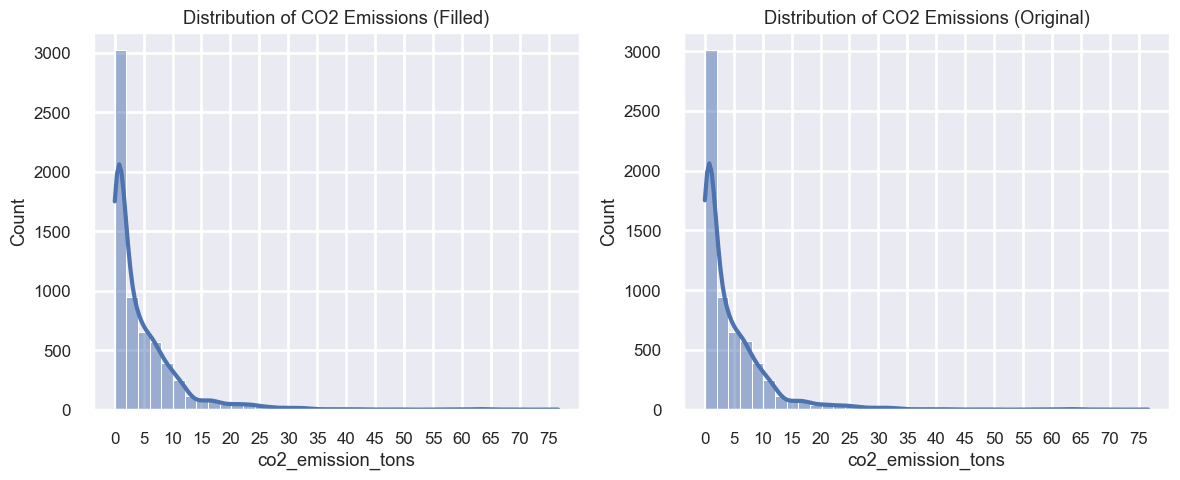

In [20]:

print("descriptive stats for filled","\n",data_filled["co2_emission_tons"].describe(),"\n",
      "descriptive stats for original","\n",data_cleaned["co2_emission_tons"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(data_filled['co2_emission_tons'], bins=30, kde=True,ax=axes[0],binwidth=2)
sns.histplot(data_cleaned['co2_emission_tons'], bins=30, kde=True,ax=axes[1],binwidth=2)
axes[0].set_xticks(np.arange(0, 80, 5))
axes[1].set_xticks(np.arange(0, 80, 5))
axes[0].set_title('Distribution of CO2 Emissions (Filled)')
axes[1].set_title('Distribution of CO2 Emissions (Original)')
plt.tight_layout()
plt.show()



* The distribution consarvated after imputation as we see in the graph and the descriptive statistic.

### 1.3.2 *`gross_inc_percap`*

The variable is MCAR. We can use simple imputation methods but we know the variable highly correlated with `co2_emission_tons`. we can try to use it as predictor.

In [ ]:

data_model_gdp = data_filled.dropna() 
X = data_model_gdp[["co2_emission_tons"]]  
y = data_model_gdp['gross_inc_percap'] 

X = sm.add_constant(X) 
model_gdp = sm.OLS(y, X).fit() 

X = model_gdp.model.exog  

descriptive stats for filled 
 count      6369.000000
mean      17154.668318
std       19842.639566
min         415.682568
25%        3438.978667
50%        9671.668674
75%       23724.113410
max      146673.241500
Name: gross_inc_percap, dtype: float64 
 descriptive stats for original 
 count      6296.000000
mean      17144.578095
std       19926.745155
min         415.682568
25%        3387.585740
50%        9597.206147
75%       23610.175872
max      146673.241500
Name: gross_inc_percap, dtype: float64


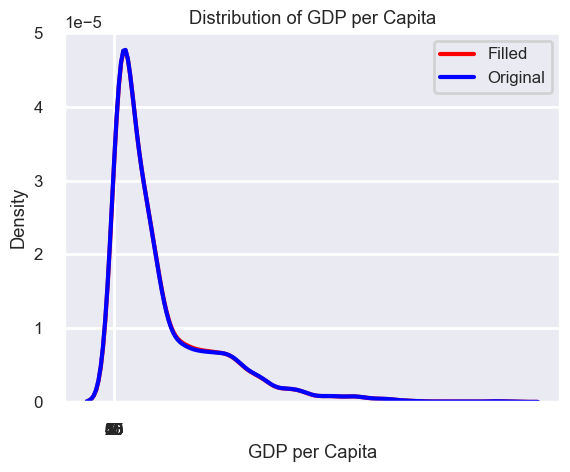

In [ ]:
missing_rows = data_filled[data_filled['gross_inc_percap'].isna()]

X_missing = missing_rows[['co2_emission_tons']] 
X_missing = sm.add_constant(X_missing)
missing_rows['gross_inc_percap'] = model_gdp.predict(X_missing)

data_filled.update(missing_rows)


print("descriptive stats for filled","\n",data_filled["gross_inc_percap"].describe(),"\n",
      "descriptive stats for original","\n",data_cleaned["gross_inc_percap"].describe())

sns.kdeplot(data_filled['gross_inc_percap'],color="red",label="Filled")
sns.kdeplot(data_cleaned['gross_inc_percap'],color="blue",label="Original")
plt.title('Distribution of GDP per Capita')
plt.xlabel('GDP per Capita')
plt.ylabel('Density')
plt.legend()
plt.xticks(range(0,80,5))
plt.show()


 Distributons of the data match. It is apropriate to fill.

### 1.3.3 *`expec_yr_school`*

Missingnes mechanism is MAR. Regression imputation is hard because missingness relation are positive with all variables. Hence mean/mode/median imputation is better option. 

<Axes: xlabel='expec_yr_school', ylabel='Density'>

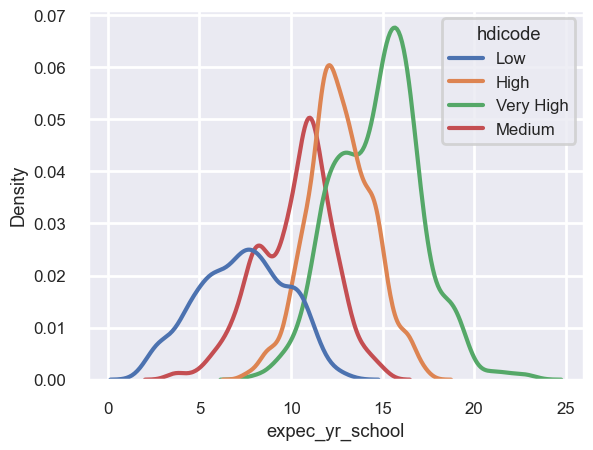

In [ ]:
sns.kdeplot(data_filled,x="expec_yr_school",hue="hdicode")

expected year in school distribution is different for different hdicode. we can use it as group. and fill with 

descriptive stats for filled 
 count    6369.000000
mean       11.965014
std         3.426035
min         1.942090
25%        10.013360
50%        12.107300
75%        14.477750
max        23.247681
Name: expec_yr_school, dtype: float64 
 descriptive stats for original 
 count    6154.000000
mean       12.005132
std         3.440935
min         1.942090
25%        10.034657
50%        12.116220
75%        14.498742
max        23.247681
Name: expec_yr_school, dtype: float64


Text(0.5, 1.0, 'Distribution of Expected Years of Schooling (Original)')

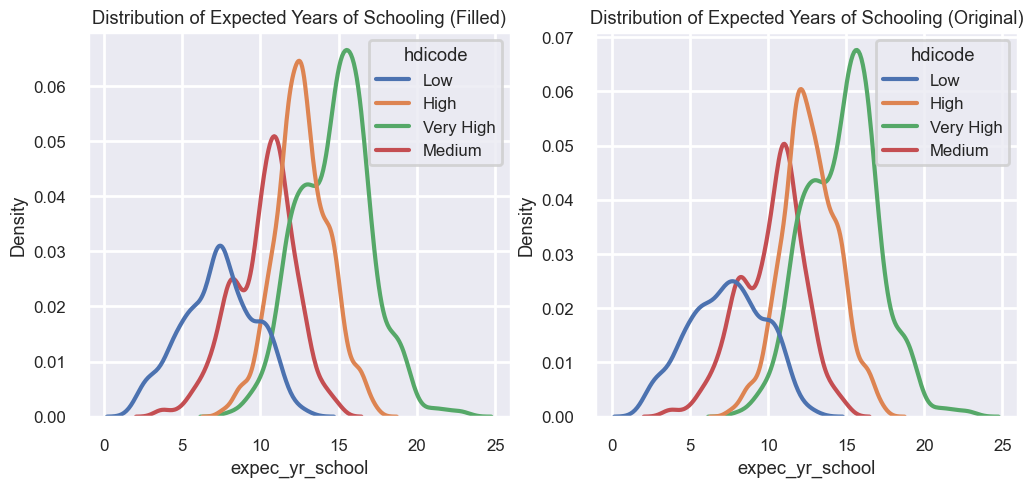

In [ ]:
data_filled_sch=data_filled.copy()
data_filled["expec_yr_school"]=data_filled['expec_yr_school'].fillna(data_filled.groupby('hdicode')['expec_yr_school'].transform('mean'))

print("descriptive stats for filled","\n",data_filled["expec_yr_school"].describe(),"\n",
      "descriptive stats for original","\n",data_cleaned["expec_yr_school"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.kdeplot(data_filled,x="expec_yr_school",hue="hdicode",ax=axes[0],label="Filled")
sns.kdeplot(data_cleaned,x="expec_yr_school",hue="hdicode",ax=axes[1],label="Original")
axes[0].set_title('Distribution of Expected Years of Schooling (Filled)')
axes[1].set_title('Distribution of Expected Years of Schooling (Original)')


Descriptive statistics are similar for both and the distribution is close to each other

### 1.3.4 *`seats_in_parliament_m_%`* and *`seats_in_parliament_m_%`*

Summation of `seats_in_parliament_m_%` and `seats_in_parliament_f_%` is 100. The missingness relation is 1. It means both values are missing in same row. Hence we try to find differences in the distribution for any categorical variable. Every country has different dynamic on this variable. We can fill the mean value by country.

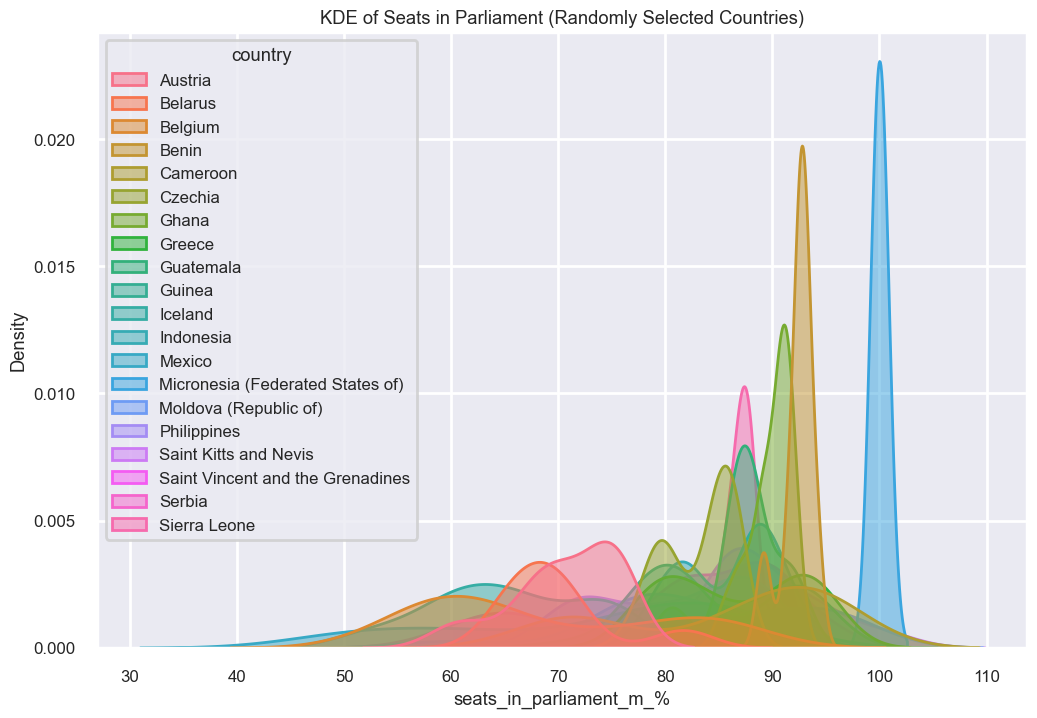

In [ ]:
np.random.seed(42)

# Randomly select 5 countries
random_countries = data_filled["country"].dropna().unique()
selected_countries = np.random.choice(random_countries, size=20, replace=False)

# Filter the dataset
data_filtered = data_filled[data_filled["country"].isin(selected_countries)]

# Create KDE plot
fig, axes = plt.subplots(1, 1, figsize=(12, 8))
sns.kdeplot(data=data_filtered, x="seats_in_parliament_m_%", hue="country", fill=True, alpha=0.5)

plt.title("KDE of Seats in Parliament (Randomly Selected Countries)")
plt.show()

The graph justify the assumption that difference country has difference distribution. Hence, I will fill missing values with mean value by country. And fill the `seats_in_parliament_f_%` with 100 - male.

In [ ]:

data_filled["seats_in_parliament_m_%"]=data_filled['seats_in_parliament_m_%'].fillna(
    data_filled.groupby('country')['seats_in_parliament_m_%'].transform('mean'))

In [ ]:
data_filled[data_filled["seats_in_parliament_f_%"].isna()]["country"].unique()

array(['Afghanistan', 'Albania', 'Bahrain', 'Belarus',
       'Bolivia (Plurinational State of)', 'Bosnia and Herzegovina',
       'Brunei Darussalam', 'Burundi', 'China', 'Congo',
       'Congo (Democratic Republic of the)', 'Djibouti', 'Ethiopia',
       'Grenada', 'Guyana', 'Haiti', 'Honduras', 'Hong Kong, China (SAR)',
       "Lao People's Democratic Republic", 'Liberia', 'Libya',
       'Marshall Islands', 'Montenegro', 'Myanmar', 'Nauru', 'Nigeria',
       'Oman', 'Palestine, State of', 'Qatar', 'Saudi Arabia', 'Serbia',
       'Sierra Leone', 'Solomon Islands', 'Somalia', 'South Sudan',
       'Timor-Leste', 'Vanuatu', 'Yemen'], dtype=object)

there are 3 coutries that has no record. We will fill the values with regional mean value. Hong kong in East Asia. Arab States is good choice for palestine.

In [ ]:
regional_mean=data_not_country.groupby("country")["seats_in_parliament_m_%"].mean()

data_filled.loc[data_filled["country"] == "Hong Kong, China (SAR)", "seats_in_parliament_m_%"] = (
    data_filled.loc[data_filled["country"] == "Hong Kong, China (SAR)", "seats_in_parliament_m_%"]
    .fillna(regional_mean.loc["East Asia and the Pacific"])
)

data_filled.loc[data_filled["country"] == "Palestine, State of", "seats_in_parliament_m_%"] = (
    data_filled.loc[data_filled["country"] == "Palestine, State of", "seats_in_parliament_m_%"]
    .fillna(regional_mean.loc["Arab States"])
)
data_filled.loc[data_filled["seats_in_parliament_f_%"].isna(), "seats_in_parliament_f_%"] = (
    100 - data_filled["seats_in_parliament_m_%"]
)



descriptive stats of 


([<matplotlib.axis.XTick at 0x1679dcfd0>,
 [Text(0, 0, '0'),
  Text(5, 0, '5'),
  Text(10, 0, '10'),
  Text(15, 0, '15'),
  Text(20, 0, '20'),
  Text(25, 0, '25'),
  Text(30, 0, '30'),
  Text(35, 0, '35'),
  Text(40, 0, '40'),
  Text(45, 0, '45'),
  Text(50, 0, '50'),
  Text(55, 0, '55'),
  Text(60, 0, '60'),
  Text(65, 0, '65'),
  Text(70, 0, '70'),
  Text(75, 0, '75')])

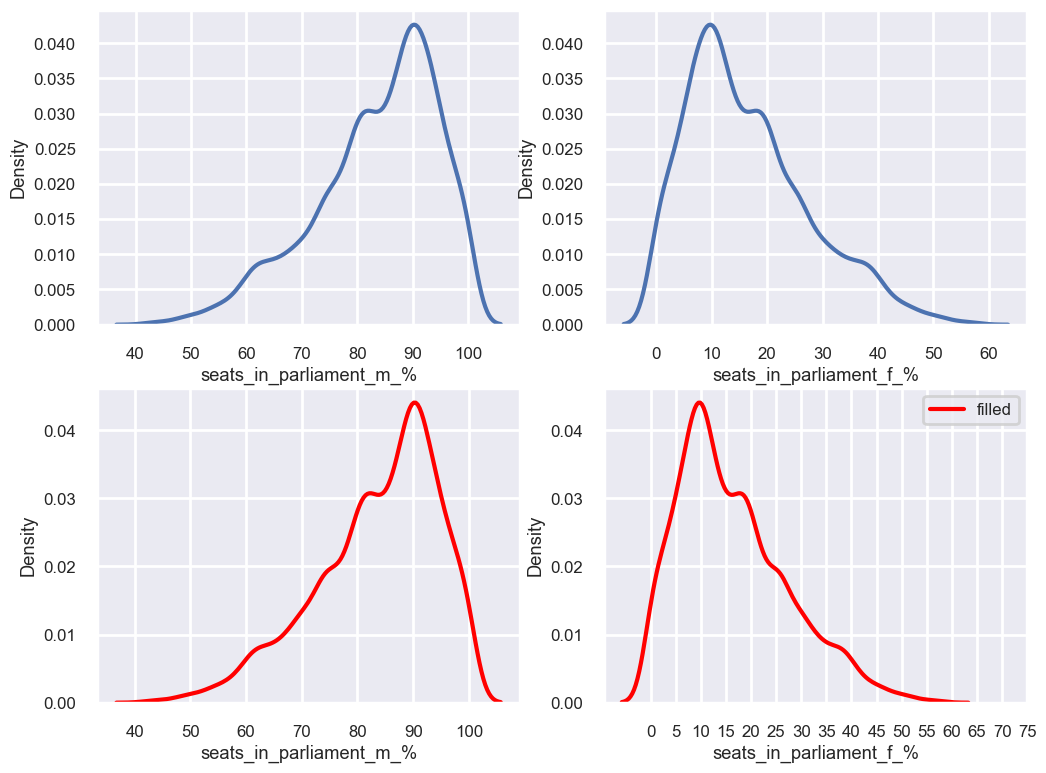

In [ ]:
print("descriptive stats of ")

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
sns.kdeplot(data_cleaned,x="seats_in_parliament_m_%",ax=axes[0,0],label="original")
sns.kdeplot(data_filled,x="seats_in_parliament_m_%",color="red",ax=axes[1,0],label="filled")
sns.kdeplot(data_cleaned,x="seats_in_parliament_f_%",ax=axes[0,1],label="original")
sns.kdeplot(data_filled,x="seats_in_parliament_f_%",color="red",ax=axes[1,1],label= "filled")
plt.legend()
plt.xticks(range(0,80,5))

the distribution is quite similar after filling. It means the imputation is good.

### 1.3.5 *`expec_yr_school_f`* and *`expec_yr_school_m`*

those has strong linear correlation with `expec_yr_school` (0.99). Regression imputation can be used.

In [ ]:
 
data_school = data_filled.dropna()
X = data_school[['expec_yr_school']] 
y = data_school['expec_yr_school_m'] 

X = sm.add_constant(X) 
model_m = sm.OLS(y, X).fit()
print(model_m.summary()) 

                            OLS Regression Results                            
Dep. Variable:      expec_yr_school_m   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.972
Method:                 Least Squares   F-statistic:                 1.361e+05
Date:                Fri, 20 Jun 2025   Prob (F-statistic):               0.00
Time:                        19:02:35   Log-Likelihood:                -2557.3
No. Observations:                3853   AIC:                             5119.
Df Residuals:                    3851   BIC:                             5131.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               1.4768      0.032     

In [ ]:
 
data_school = data_filled.dropna()
X = data_school[['expec_yr_school']] 
y = data_school['expec_yr_school_f'] 

X = sm.add_constant(X) 
model_f = sm.OLS(y, X).fit()
print(model_f.summary()) 

                            OLS Regression Results                            
Dep. Variable:      expec_yr_school_f   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                 1.847e+05
Date:                Fri, 20 Jun 2025   Prob (F-statistic):               0.00
Time:                        19:02:35   Log-Likelihood:                -2895.4
No. Observations:                3853   AIC:                             5795.
Df Residuals:                    3851   BIC:                             5807.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -1.4651      0.035    -

the models for both male and female seem good fit in the output. we may use these models.

In [ ]:

missing_rows = data_filled[data_filled['expec_yr_school_m'].isna()]

X_missing = missing_rows[['expec_yr_school']] 
X_missing = sm.add_constant(X_missing)
missing_rows['expec_yr_school_m'] = model_m.predict(X_missing)

data_filled.update(missing_rows)


missing_rows = data_filled[data_filled['expec_yr_school_f'].isna()]

X_missing = missing_rows[['expec_yr_school']] 
X_missing = sm.add_constant(X_missing)
missing_rows['expec_yr_school_f'] = model_f.predict(X_missing)

data_filled.update(missing_rows)

Text(0.5, 1.0, 'Expected Years of Schooling (Female)')

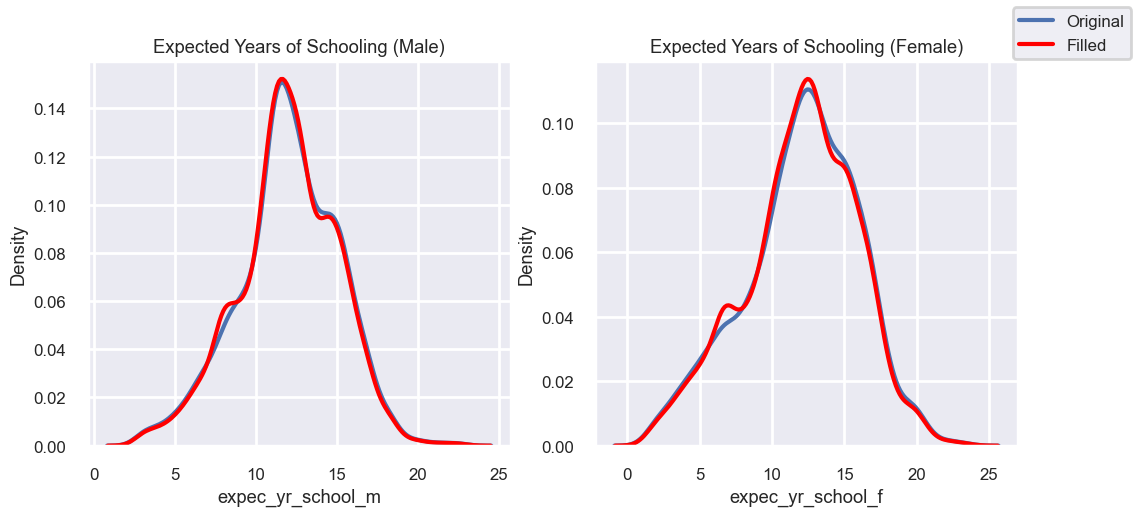

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.kdeplot(data_cleaned,x="expec_yr_school_m",ax= axes[0])
sns.kdeplot(data_filled,x="expec_yr_school_m",color="red",ax=axes[0])
sns.kdeplot(data_cleaned,x="expec_yr_school_f",ax= axes[1])
sns.kdeplot(data_filled,x="expec_yr_school_f",color="red",ax=axes[1])
fig.legend(labels=["Original", "Filled"], loc="upper right")

# Set titles for subplots
axes[0].set_title("Expected Years of Schooling (Male)")
axes[1].set_title("Expected Years of Schooling (Female)")

the distributions quite similar after filling.

### 1.3.6 *`hdi`*

In [ ]:
data_filled["hdi"]= data_cleaned["hdi"]
# Initialize MICE imputer with more iterations
mice_imputer = IterativeImputer(max_iter=50, random_state=42)
best_predictors=["hdi", "life_expectancy", "gross_inc_percap", "mean_yr_school", "secondary_education_f_%", "secondary_education_m_%"
                 ]+list(encoded_countries.columns)
# Apply MICE imputation
data_imputed = mice_imputer.fit_transform(data_filled[best_predictors])

# Convert back to DataFrame
data_filled[["hdi"]] = pd.DataFrame(data_imputed[:, 0], columns=["hdi"])

while data_filled["hdi"].isna().sum() > 0:
    data_filled["hdi"] = mice_imputer.fit_transform(data_filled[["hdi"]])[:, 0]




<Axes: xlabel='hdi', ylabel='Density'>

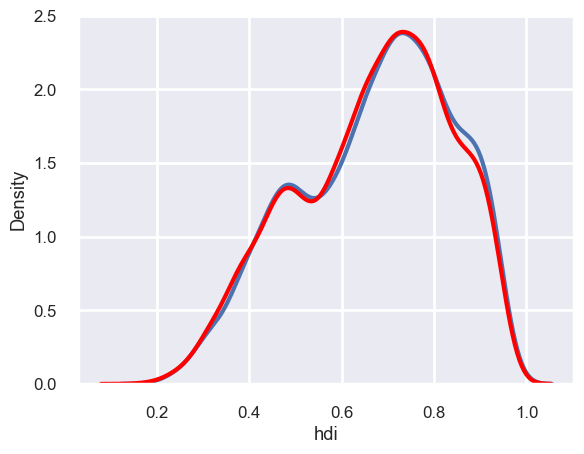

In [ ]:
sns.kdeplot(data_cleaned,x="hdi")
sns.kdeplot(data_filled,x="hdi",color="red")

the result quite similar.

### 1.3.7 *`mean_yr_school`*

all three variables have positive missingnes relation with other variable. Hence we cannot use regression imputation. 
we will try to use MICE.

I will chose the variables in two condition: 

* correlation with mean yers in scool
* missingnes relationship with mean year school

higher correlation and near to zero missingness relation are good choice. Also, will use the encoded country list.

In [ ]:

# Select best predictors based on correlation
best_predictors = ["expec_yr_school","expec_yr_school_f","expec_yr_school_m","life_expectancy","gross_inc_percap","co2_emission_tons",
                   "mat_footprint_percap_tons","gender_inequality"] + list(encoded_countries.columns)

# Create subset with selected predictors
data_subset = data_filled[["mean_yr_school"] + best_predictors]

# Initialize MICE imputer with more iterations
mice_imputer = IterativeImputer(max_iter=50, random_state=42)

# Apply MICE imputation
data_imputed = mice_imputer.fit_transform(data_subset)

# Convert back to DataFrame
data_filled["mean_yr_school",] = pd.DataFrame(data_imputed[:, 0], columns=["mean_yr_school"])

while data_filled["mean_yr_school"].isna().sum() > 0:
    data_filled["mean_yr_school"] = mice_imputer.fit_transform(data_filled[["mean_yr_school"] + best_predictors])[:, 0]
    
data_filled["mean_yr_school"].isna().sum()


0

<Axes: xlabel='mean_yr_school', ylabel='Density'>

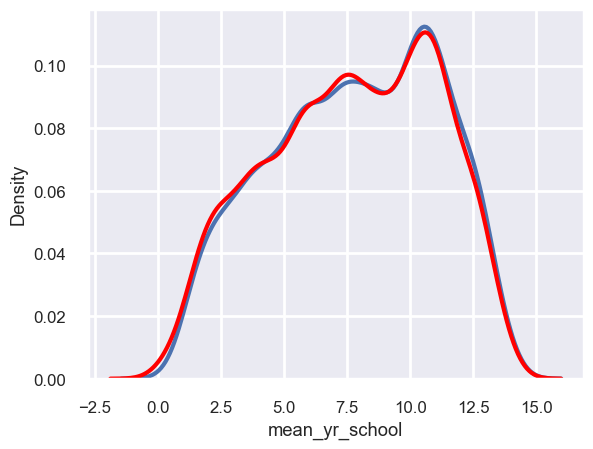

In [ ]:

sns.kdeplot(data_cleaned,x="mean_yr_school",)
sns.kdeplot(data_filled,x="mean_yr_school",color="red")

The distribution is protected after imputation. 

### 1.3.8 *`mean_yr_school_f`* and *`mean_yr_school_m`*


In [ ]:

# Select best predictors based on correlation
best_predictors = ["mean_yr_school","expec_yr_school","expec_yr_school_f","expec_yr_school_m","life_expectancy","gross_inc_percap","co2_emission_tons",
                   "mat_footprint_percap_tons","gender_inequality"] + list(encoded_countries.columns)

# Create subset with selected predictors
data_subset = data_filled[["mean_yr_school_f"] + best_predictors]

# Initialize MICE imputer with more iterations
mice_imputer = IterativeImputer(max_iter=50, random_state=42)

# Apply MICE imputation
data_imputed = mice_imputer.fit_transform(data_subset)

# Convert back to DataFrame
data_filled["mean_yr_school_f",] = pd.DataFrame(data_imputed[:, 0], columns=["mean_yr_school_f"])

while data_filled["mean_yr_school_f"].isna().sum() > 0:
    data_filled["mean_yr_school_f"] = mice_imputer.fit_transform(data_filled[["mean_yr_school_f"] + best_predictors])[:, 0]
    
data_filled["mean_yr_school_f"].isna().sum()

0

In [ ]:

# Select best predictors based on correlation
best_predictors = ["mean_yr_school","mean_yr_school_f","expec_yr_school","expec_yr_school_f","expec_yr_school_m","life_expectancy","gross_inc_percap","co2_emission_tons",
                   "mat_footprint_percap_tons","gender_inequality"] + list(encoded_countries.columns)

# Create subset with selected predictors
data_subset = data_filled[["mean_yr_school_m"] + best_predictors]

# Initialize MICE imputer with more iterations
mice_imputer = IterativeImputer(max_iter=50, random_state=42)

# Apply MICE imputation
data_imputed = mice_imputer.fit_transform(data_subset)

# Convert back to DataFrame
data_filled["mean_yr_school_m",] = pd.DataFrame(data_imputed[:, 0], columns=["mean_yr_school_m"])

while data_filled["mean_yr_school_m"].isna().sum() > 0:
    data_filled["mean_yr_school_m"] = mice_imputer.fit_transform(data_filled[["mean_yr_school_m"] + best_predictors])[:, 0]
    
data_filled["mean_yr_school_m"].isna().sum()

0

Text(0.5, 1.0, 'Mean Year of Schooling (Female)')

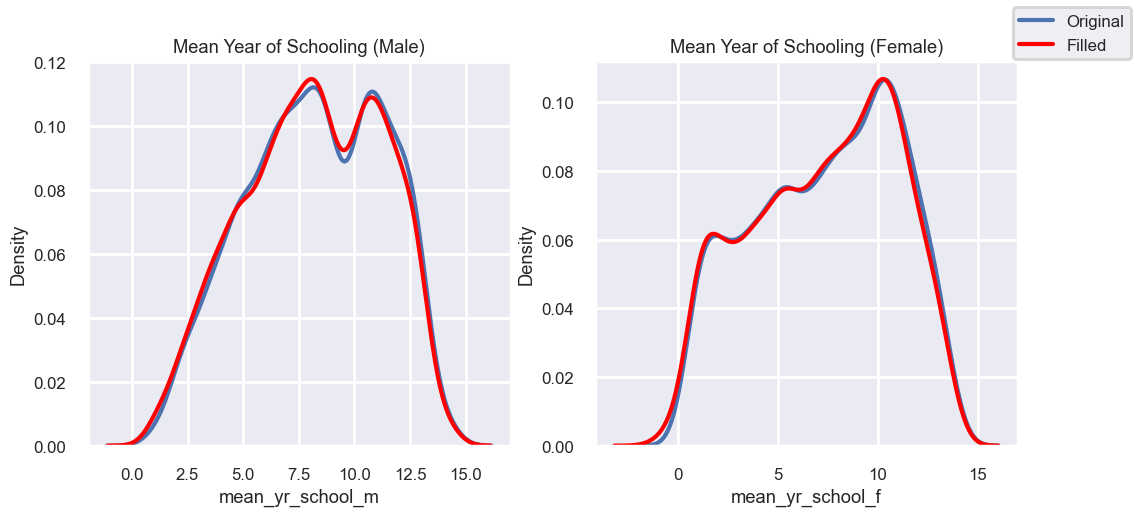

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.kdeplot(data_cleaned,x="mean_yr_school_m",ax= axes[0])
sns.kdeplot(data_filled,x="mean_yr_school_m",color="red",ax=axes[0])
sns.kdeplot(data_cleaned,x="mean_yr_school_f",ax= axes[1])
sns.kdeplot(data_filled,x="mean_yr_school_f",color="red",ax=axes[1])

fig.legend(labels=["Original", "Filled"], loc="upper right")
# Set titles for subplots
axes[0].set_title("Mean Year of Schooling (Male)")
axes[1].set_title("Mean Year of Schooling (Female)")


### 1.3.9 *`secondary_eduction_f_%`* and *`secondary_education_m_%`*

In [ ]:
best_predictors = ["hdi_rank_2022","expec_yr_school_f","mean_yr_school_f","life_expec_f","gross_inc_percap","gender_inequality"] + list(encoded_countries.columns)

# Create subset with selected predictors
data_subset = data_filled[["secondary_education_f_%"] + best_predictors]

# Initialize MICE imputer with more iterations
mice_imputer = IterativeImputer(max_iter=50, random_state=42)

# Apply MICE imputation
data_imputed = mice_imputer.fit_transform(data_subset)

# Convert back to DataFrame
data_filled["secondary_education_f_%",] = pd.DataFrame(data_imputed[:, 0], columns=["secondary_education_f_%"])

while data_filled["secondary_education_f_%"].isna().sum() > 0:
    data_filled["secondary_education_f_%"] = mice_imputer.fit_transform(data_filled[["secondary_education_f_%"] + best_predictors])[:, 0]
    
data_filled["secondary_education_f_%"].isna().sum()


0

In [ ]:
best_predictors = ["hdi_rank_2022","expec_yr_school_m","mean_yr_school_m","life_expec_m","gross_inc_percap","gender_inequality"] + list(encoded_countries.columns)

# Create subset with selected predictors
data_subset = data_filled[["secondary_education_m_%"] + best_predictors]

# Initialize MICE imputer with more iterations
mice_imputer = IterativeImputer(max_iter=50, random_state=42)

# Apply MICE imputation
data_imputed = mice_imputer.fit_transform(data_subset)

# Convert back to DataFrame
data_filled["secondary_education_m_%",] = pd.DataFrame(data_imputed[:, 0], columns=["secondary_education_m_%"])

while data_filled["secondary_education_m_%"].isna().sum() > 0:
    data_filled["secondary_education_m_%"] = mice_imputer.fit_transform(data_filled[["secondary_education_m_%"] + best_predictors])[:, 0]
    
data_filled["secondary_education_m_%"].isna().sum()

0

Text(0.5, 1.0, 'Secondary Education Percentage (Female)')

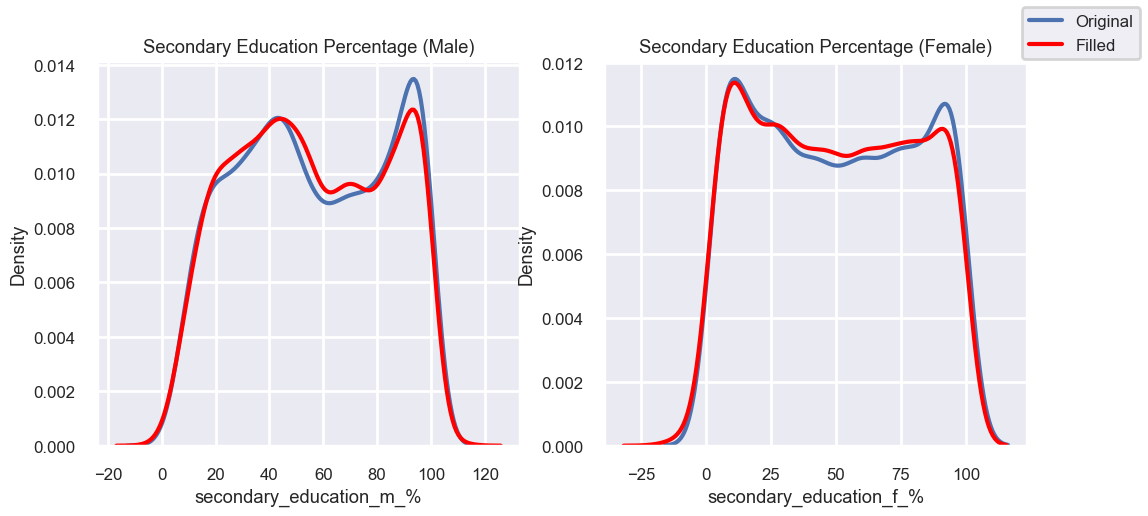

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.kdeplot(data_cleaned,x="secondary_education_m_%",ax= axes[0])
sns.kdeplot(data_filled,x="secondary_education_m_%",color="red",ax=axes[0])
sns.kdeplot(data_cleaned,x="secondary_education_f_%",ax= axes[1])
sns.kdeplot(data_filled,x="secondary_education_f_%",color="red",ax=axes[1])

fig.legend(labels=["Original", "Filled"], loc="upper right")
# Set titles for subplots
axes[0].set_title("Secondary Education Percentage (Male)")
axes[1].set_title("Secondary Education Percentage (Female)")

### 1.3.10 *`gross_inc_percap_f`* and *`gross_inc_percap_m`*

In [ ]:
best_predictors = ["gross_inc_percap","co2_emission_tons","expec_yr_school","mean_yr_school",
                   "life_expectancy",] + list(encoded_countries.columns)

# Create subset with selected predictors
data_subset = data_filled[["gross_inc_percap_f"] + best_predictors]

# Initialize MICE imputer with more iterations
mice_imputer = IterativeImputer(max_iter=50, random_state=42)

# Apply MICE imputation
data_imputed = mice_imputer.fit_transform(data_subset)

# Convert back to DataFrame
data_filled["gross_inc_percap_f",] = pd.DataFrame(data_imputed[:, 0], columns=["gross_inc_percap_f"])

while data_filled["gross_inc_percap_f"].isna().sum() > 0:
    data_filled["gross_inc_percap_f"] = mice_imputer.fit_transform(data_filled[["gross_inc_percap_f"] + best_predictors])[:, 0]
    
data_filled["gross_inc_percap_f"].isna().sum()

0

In [ ]:
best_predictors = ["gross_inc_percap","co2_emission_tons","expec_yr_school_m","mean_yr_school_m",
                   "life_expec_m",] + list(encoded_countries.columns)

# Create subset with selected predictors
data_subset = data_filled[["gross_inc_percap_m"] + best_predictors]

# Initialize MICE imputer with more iterations
mice_imputer = IterativeImputer(max_iter=50, random_state=42)

# Apply MICE imputation
data_imputed = mice_imputer.fit_transform(data_subset)

# Convert back to DataFrame
data_filled["gross_inc_percap_m",] = pd.DataFrame(data_imputed[:, 0], columns=["gross_inc_percap_m"])

while data_filled["gross_inc_percap_m"].isna().sum() > 0:
    data_filled["gross_inc_percap_m"] = mice_imputer.fit_transform(data_filled[["gross_inc_percap_m"] + best_predictors])[:, 0]
    
data_filled["gross_inc_percap_m"].isna().sum()

0

Text(0.5, 1.0, 'GDP (Female)')

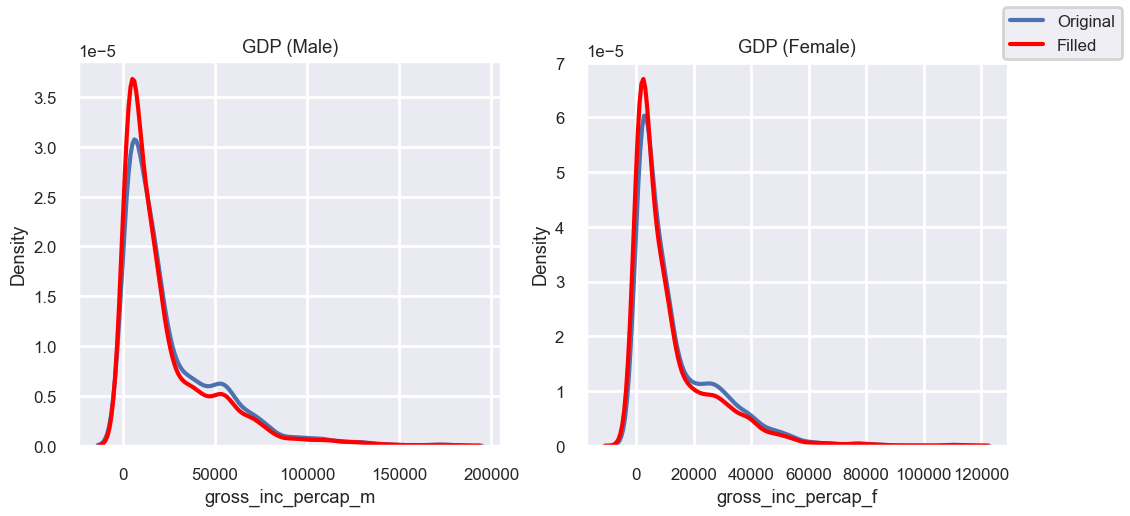

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.kdeplot(data_cleaned,x="gross_inc_percap_m",ax= axes[0])
sns.kdeplot(data_filled,x="gross_inc_percap_m",color="red",ax=axes[0])
sns.kdeplot(data_cleaned,x="gross_inc_percap_f",ax= axes[1])
sns.kdeplot(data_filled,x="gross_inc_percap_f",color="red",ax=axes[1])

fig.legend(labels=["Original", "Filled"], loc="upper right")
# Set titles for subplots
axes[0].set_title("GDP (Male)")
axes[1].set_title("GDP (Female)")

### 1.3.11 *`mat_footprint_percap_tons`*

In [ ]:
data_model_co2 = data_filled.dropna()  
X = data_model_co2["co2_emission_tons"] 
y = data_model_co2['mat_footprint_percap_tons'] 

X = sm.add_constant(X) 
model = sm.OLS(y, X).fit()
print(model.summary()) 


                                OLS Regression Results                               
Dep. Variable:     mat_footprint_percap_tons   R-squared:                       0.701
Model:                                   OLS   Adj. R-squared:                  0.700
Method:                        Least Squares   F-statistic:                     9008.
Date:                       Fri, 20 Jun 2025   Prob (F-statistic):               0.00
Time:                               20:35:05   Log-Likelihood:                -12940.
No. Observations:                       3853   AIC:                         2.588e+04
Df Residuals:                           3851   BIC:                         2.590e+04
Df Model:                                  1                                         
Covariance Type:                   nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

descriptive stats for filled 
 count    6369.000000
mean        4.643439
std         6.440046
min         0.019352
25%         0.584032
50%         2.295445
75%         6.449978
max        76.612949
Name: co2_emission_tons, dtype: float64 
 descriptive stats for original 
 count    6317.000000
mean        4.588072
std         6.391256
min         0.019352
25%         0.577593
50%         2.276379
75%         6.406585
max        76.612949
Name: co2_emission_tons, dtype: float64


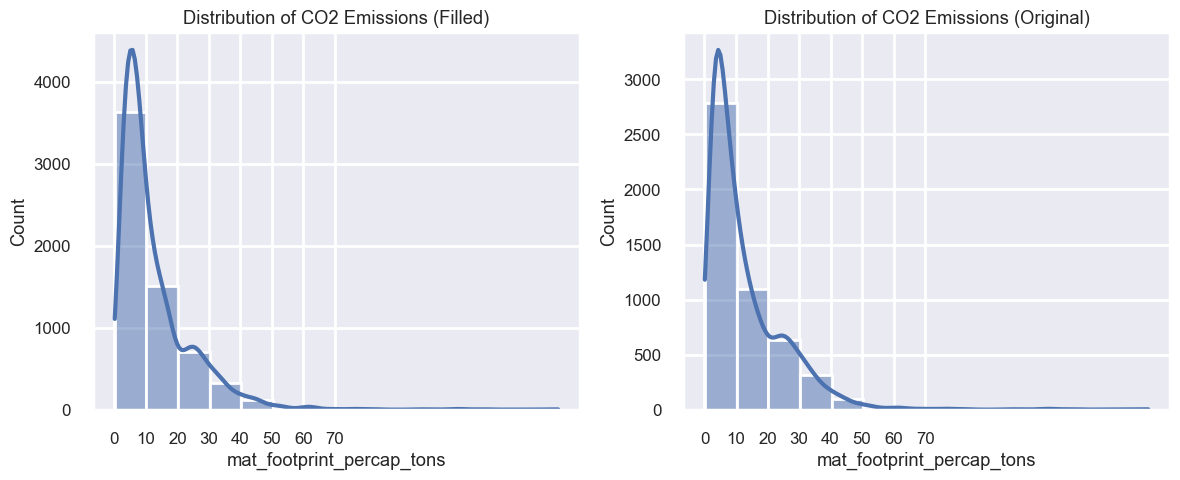

In [ ]:

missing_rows = data_filled[data_filled['mat_footprint_percap_tons'].isna()]

X_missing = missing_rows[['co2_emission_tons']] 
X_missing = sm.add_constant(X_missing)
missing_rows['mat_footprint_percap_tons'] = model.predict(X_missing)

data_filled.update(missing_rows)


print("descriptive stats for filled","\n",data_filled["co2_emission_tons"].describe(),"\n",
      "descriptive stats for original","\n",data_cleaned["co2_emission_tons"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(data_filled['mat_footprint_percap_tons'], bins=30, kde=True,ax=axes[0],binwidth=10)
sns.histplot(data_cleaned['mat_footprint_percap_tons'], bins=30, kde=True,ax=axes[1],binwidth=10)
axes[0].set_xticks(np.arange(0, 80, 10))
axes[1].set_xticks(np.arange(0, 80, 10))
axes[0].set_title('Distribution of CO2 Emissions (Filled)')
axes[1].set_title('Distribution of CO2 Emissions (Original)')
plt.tight_layout()
plt.show()

### 1.3.12 *`labour_participation_f_%`* and *`labour_participation_m_%`*

In [ ]:
data_filled["labour_participation_f_%"]= data_cleaned["labour_participation_f_%"]
data_filled["labour_participation_m_%"]= data_cleaned["labour_participation_m_%"]
# Select best predictors based on correlation
best_predictors = [
    "life_expectancy", "gross_inc_percap", "gender_inequality",
    "secondary_education_m_%", "secondary_education_f_%", "seats_in_parliament_f_%","seats_in_parliament_f_%",
    "co2_emission_tons", "mat_footprint_percap_tons"
]

# Ensure all column names are strings
data_filled.columns = data_filled.columns.astype(str)

# Create subset with selected predictors
data_subset = data_filled[["labour_participation_m_%", "labour_participation_f_%"] + best_predictors]

# Initialize MICE imputer with more iterations
mice_imputer = IterativeImputer(max_iter=50, random_state=42)

# Apply MICE imputation
data_imputed = mice_imputer.fit_transform(data_subset)

# Convert back to DataFrame
data_filled[["labour_participation_m_%", "labour_participation_f_%"]] = pd.DataFrame(
    data_imputed[:, :2], columns=["labour_participation_m_%", "labour_participation_f_%"]
)

# Ensure all missing values are filled
while data_filled["labour_participation_m_%"].isna().sum() > 0 or data_filled["labour_participation_f_%"].isna().sum() > 0:
    data_filled[["labour_participation_m_%", "labour_participation_f_%"]] = mice_imputer.fit_transform(data_filled[["labour_participation_m_%", "labour_participation_f_%"] + best_predictors])[:, :2]

# Check remaining missing values
print("Remaining missing values in labour_participation_m_%:", data_filled["labour_participation_m_%"].isna().sum())
print("Remaining missing values in labour_participation_f_%:", data_filled["labour_participation_f_%"].isna().sum())


Remaining missing values in labour_participation_m_%: 0
Remaining missing values in labour_participation_f_%: 0


Text(0.5, 1.0, 'labour male')

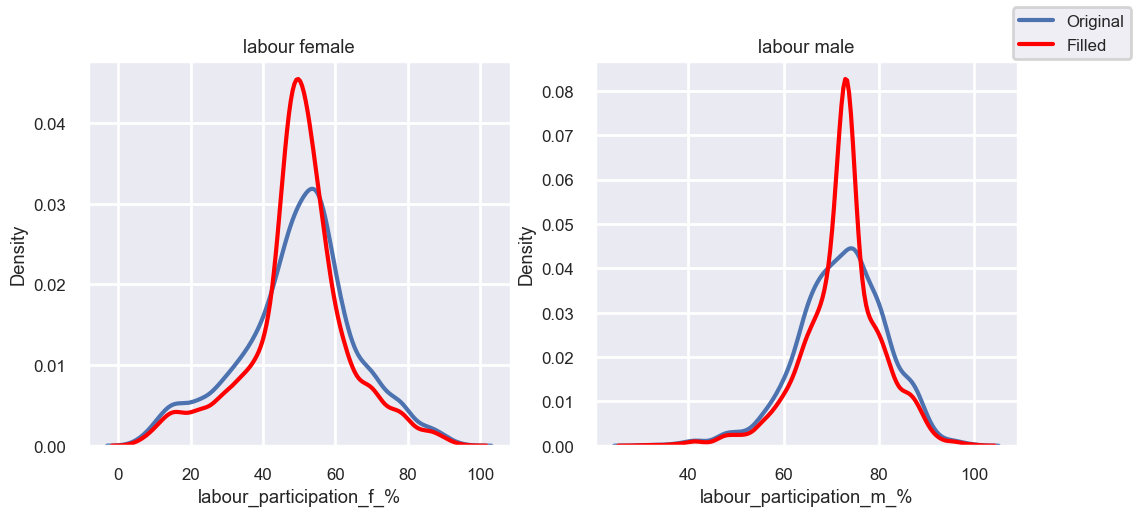

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.kdeplot(data_cleaned,x="labour_participation_f_%",ax= axes[0])
sns.kdeplot(data_filled,x="labour_participation_f_%",color="red",ax=axes[0])
sns.kdeplot(data_cleaned,x="labour_participation_m_%",ax= axes[1])
sns.kdeplot(data_filled,x="labour_participation_m_%",color="red",ax=axes[1])

fig.legend(labels=["Original", "Filled"], loc="upper right")
# Set titles for subplots
axes[0].set_title("labour female")
axes[1].set_title("labour male")

### 1.3.13 `hdi_f` and  `hdi_m`

In [ ]:
data_filled["hdi_f"]=data_cleaned["hdi_f"]
data_filled["hdi_m"]=data_cleaned["hdi_m"]
best_predictors_hdi_m = [
    "hdi", "mean_yr_school_m", "expec_yr_school_m", "gross_inc_percap_m",
     "life_expec_m",
    "hdi_rank_2022", "co2_emission_tons", "mat_footprint_percap_tons",
    "seats_in_parliament_m_%", 
] + list(encoded_countries.columns)

best_predictors_hdi_f = [
    "hdi", "mean_yr_school_f", "expec_yr_school_f", "gross_inc_percap_f",
     "life_expec_f",
    "hdi_rank_2022", "co2_emission_tons", "mat_footprint_percap_tons",
    "seats_in_parliament_f_%",
] + list(encoded_countries.columns)
# Ensure all column names are strings
data_filled.columns = data_filled.columns.astype(str)

# Create subset with selected predictors
data_subset_hdi_m = data_filled[["hdi_m"] + best_predictors_hdi_m]
data_subset_hdi_f = data_filled[["hdi_f"] + best_predictors_hdi_f]

# Initialize KNN imputer
knn_imputer = KNNImputer(n_neighbors=3, weights="distance")

# Apply KNN imputation for hdi_m
data_imputed_hdi_m = knn_imputer.fit_transform(data_subset_hdi_m)
data_filled["hdi_m"] = pd.DataFrame(data_imputed_hdi_m[:, 0], columns=["hdi_m"])

# Apply KNN imputation for hdi_f
data_imputed_hdi_f = knn_imputer.fit_transform(data_subset_hdi_f)
data_filled["hdi_f"] = pd.DataFrame(data_imputed_hdi_f[:, 0], columns=["hdi_f"])

# Check remaining missing values
print("Remaining missing values in hdi_m:", data_filled["hdi_m"].isna().sum())
print("Remaining missing values in hdi_f:", data_filled["hdi_f"].isna().sum())


Remaining missing values in hdi_m: 0
Remaining missing values in hdi_f: 0


Text(0.5, 1.0, 'hdi male')

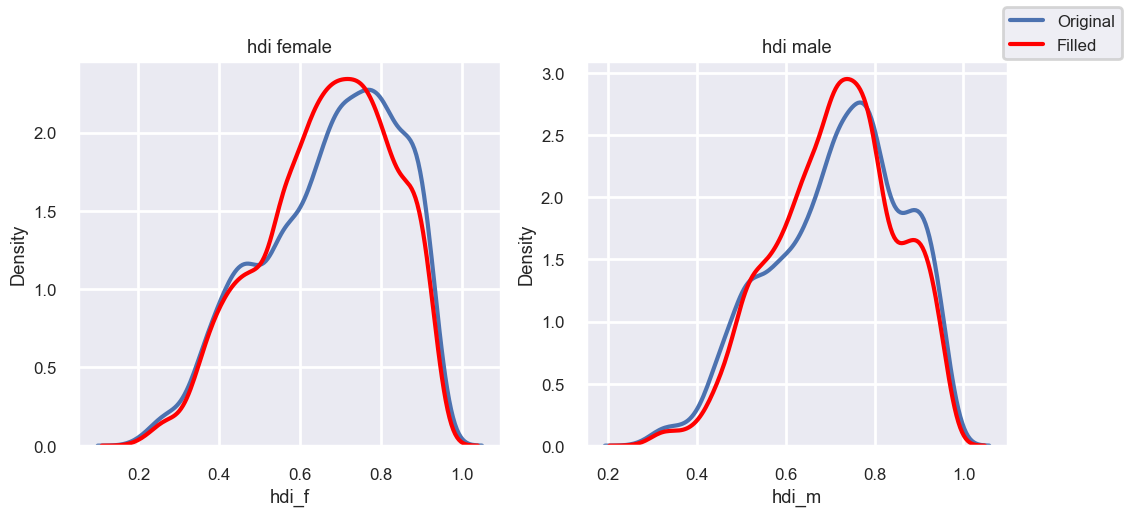

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.kdeplot(data_cleaned,x="hdi_f",ax= axes[0])
sns.kdeplot(data_filled,x="hdi_f",color="red",ax=axes[0])
sns.kdeplot(data_cleaned,x="hdi_m",ax= axes[1])
sns.kdeplot(data_filled,x="hdi_m",color="red",ax=axes[1])

fig.legend(labels=["Original", "Filled"], loc="upper right")
# Set titles for subplots
axes[0].set_title("hdi female")
axes[1].set_title("hdi male")

### 1.3.14 *`gender_inequality`*

In [ ]:
data_filled["gender_inequality"]= data_cleaned["gender_inequality"]

best_predictors_gender_inequality = [
    "hdi", "hdi_f", "hdi_m", "mean_yr_school_f", "mean_yr_school_m",
    "expec_yr_school_f", "expec_yr_school_m",
     "seats_in_parliament_f_%","seats_in_parliament_m_%"
] + list(encoded_countries.columns)

# Ensure all column names are strings
data_filled.columns = data_filled.columns.astype(str)

# Create subset with selected predictors
data_subset_gender_inequality = data_filled[["gender_inequality"] + best_predictors_gender_inequality]

# Initialize MICE imputer with more iterations
mice_imputer = IterativeImputer(max_iter=50, random_state=42)

# Apply MICE imputation for gender_inequality
data_imputed_gender_inequality = mice_imputer.fit_transform(data_subset_gender_inequality)
data_filled["gender_inequality"] = pd.DataFrame(data_imputed_gender_inequality[:, 0], columns=["gender_inequality"])

# Ensure all missing values are filled
while data_filled["gender_inequality"].isna().sum() > 0:
    data_filled["gender_inequality"] = mice_imputer.fit_transform(data_filled[["gender_inequality"] + best_predictors_gender_inequality])[:, 0]

# Check remaining missing values
print("Remaining missing values in gender_inequality:", data_filled["gender_inequality"].isna().sum())


Remaining missing values in gender_inequality: 0


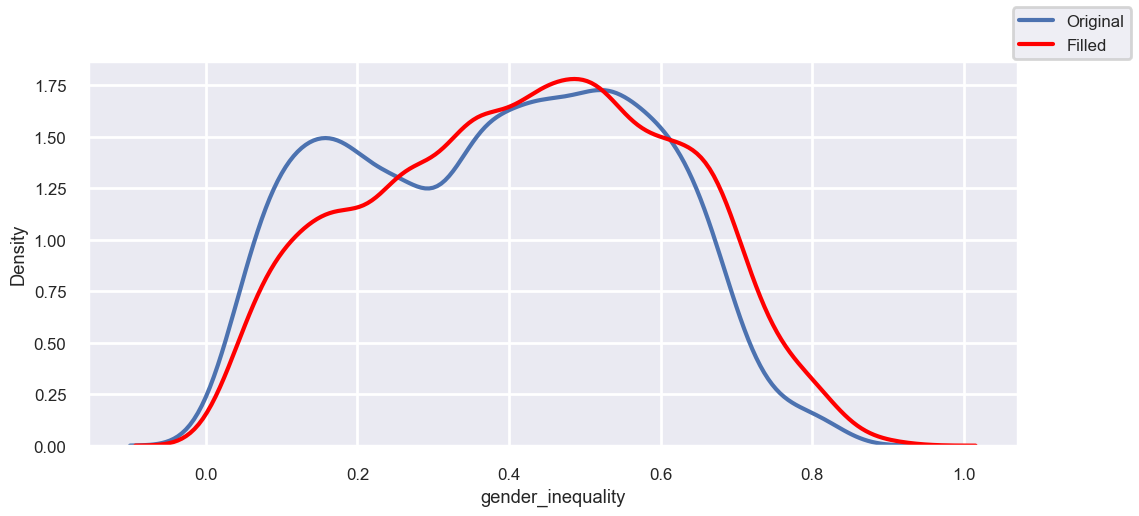

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(12, 5))
sns.kdeplot(data_cleaned,x="gender_inequality")
sns.kdeplot(data_filled,x="gender_inequality",color="red")
fig.legend(labels=["Original", "Filled"], loc="upper right")
# Set titles for subplots


### 1.3.15 *`gender_development`*

In [ ]:
data_filled["gender_development"]= data_cleaned["gender_development"]
# Select best predictors for MICE
best_predictors_gender_development = [
    "hdi_f", "hdi_m", "hdi", "mean_yr_school_f", "mean_yr_school_m",
    "expec_yr_school_f", "expec_yr_school_m", "gross_inc_percap",
     "gender_inequality"] +list(encoded_countries)

# Ensure all column names are strings
data_filled.columns = data_filled.columns.astype(str)

# Create subset with selected predictors
data_subset_gender_development = data_filled[["gender_development"] + best_predictors_gender_development]

# Initialize MICE imputer with more iterations
mice_imputer = IterativeImputer(max_iter=50, random_state=42)

# Apply MICE imputation for gender_development
data_imputed_gender_development = mice_imputer.fit_transform(data_subset_gender_development)
data_filled["gender_development"] = pd.DataFrame(data_imputed_gender_development[:, 0], columns=["gender_development"])

# Ensure all missing values are filled
while data_filled["gender_development"].isna().sum() > 0:
    data_filled["gender_development"] = mice_imputer.fit_transform(data_filled[["gender_development"] + best_predictors_gender_development])[:, 0]

# Check remaining missing values
print("Remaining missing values in gender_development:", data_filled["gender_development"].isna().sum())


Remaining missing values in gender_development: 0


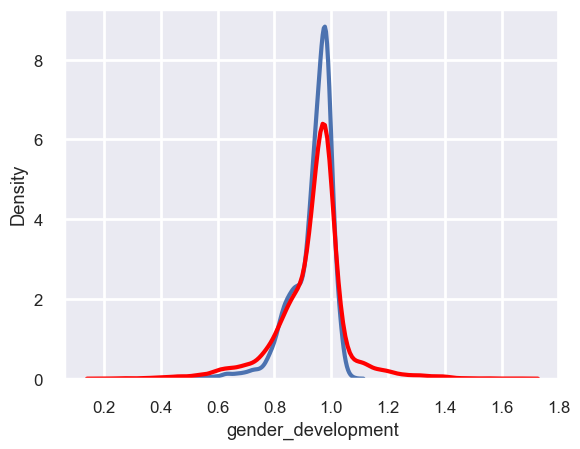

In [ ]:
sns.kdeplot(data_cleaned,x="gender_development")
sns.kdeplot(data_filled,x="gender_development",color="red")
fig.legend(labels=["Original", "Filled"], loc="upper right")



# 2. CDA

### 1- What is the relationship between GDP per capita and HDI across countries?

In [ ]:
data_filled = data_filled[data_cleaned.columns]



In [85]:
from scipy.stats import spearmanr

# Drop missing values
df_corr = data[['gross_inc_percap', 'hdi']].dropna()

# Convert to numeric
df_corr['gross_inc_percap'] = pd.to_numeric(df_corr['gross_inc_percap'], errors='coerce')
df_corr['hdi'] = pd.to_numeric(df_corr['hdi'], errors='coerce')
df_corr = df_corr.dropna()

# Spearman rank correlation
rho, pval = spearmanr(df_corr['gross_inc_percap'], df_corr['hdi'])
print(f"Spearman correlation: {rho:.3f}")
print(f"P-value: {pval:.3e}")

Spearman correlation: 0.947
P-value: 0.000e+00


There is a very strong positive Spearman correlation (ρ = 0.947, p < 0.001) between GDP per capita and HDI, indicating that as income increases, HDI tends to increase as well. This confirms a strong monotonic relationship between economic development and human development.

### 2- How has the Human Development Index (HDI) changed over time globally and across different development groups (Low, Medium, High, Very High)?

In [ ]:
# 1. Global HDI trend over time
model_global = smf.ols('hdi ~ year', data=data_filled).fit()
print("Global HDI trend over time:\n", model_global.summary())

# 2. HDI differences across development groups
anova_dev = smf.ols('hdi ~ C(hdicode)', data=data_filled).fit()
anova_table = sm.stats.anova_lm(anova_dev, typ=2)
print("\nANOVA: HDI across development groups:\n", anova_table)

# 3. HDI change over time across development groups (Two-way ANOVA with interaction)
model_interaction = smf.ols('hdi ~ C(hdicode) * year', data=data_filled).fit()
anova_interaction = sm.stats.anova_lm(model_interaction, typ=2)
print("\nTwo-way ANOVA: HDI ~ dev_group * year:\n", anova_interaction)

Global HDI trend over time:
                             OLS Regression Results                            
Dep. Variable:                    hdi   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.068
Method:                 Least Squares   F-statistic:                     467.5
Date:                Fri, 20 Jun 2025   Prob (F-statistic):          4.24e-100
Time:                        21:11:48   Log-Likelihood:                 2637.6
No. Observations:                6369   AIC:                            -5271.
Df Residuals:                    6367   BIC:                            -5258.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -8.4610  

HDI has steadily increased over time worldwide.
* Significant differences exist in HDI between development groups.
* However, all development groups experienced similar trends in HDI change over time. Any group has not specific acceleration or deceleration.


### 3- Do countries with higher development levels contribute disproportionately more to CO₂ emissions per capita?

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Ensure group variable is string or category
data_filled['hdicode'] = data_filled['hdicode'].astype(str)

# Run one-way ANOVA
model = ols('co2_emission_tons ~ C(hdicode)', data=data_filled).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                   sum_sq      df            F  PR(>F)
C(hdicode)  100335.033337     3.0  1299.835818     0.0
Residual    163772.603244  6365.0          NaN     NaN


This very small p-value (< 0.05) indicates statistically significant differences in mean CO₂ emissions per capita across the HDI groups (Low, Medium, High, Very High). We can proceed Tukey test.

In [ ]:


# Ensure group labels are strings (or convert to category)
data_filled['hdicode'] = data_filled['hdicode'].astype(str)

# Run Tukey HSD test
tukey = pairwise_tukeyhsd(endog=data_filled['co2_emission_tons'],
                          groups=data_filled['hdicode'],
                          alpha=0.05)

print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1   group2  meandiff p-adj  lower   upper  reject
------------------------------------------------------
  High       Low  -2.9177   0.0 -3.4287 -2.4068   True
  High    Medium  -1.8772   0.0 -2.3544 -1.4001   True
  High Very High   6.6181   0.0  6.1942   7.042   True
   Low    Medium   1.0405   0.0  0.5127  1.5683   True
   Low Very High   9.5358   0.0  9.0556 10.0161   True
Medium Very High   8.4953   0.0  8.0513  8.9394   True
------------------------------------------------------


All pairwise group comparisons have p-adj = 0.0, meaning every pair differs significantly. Here’s the interpretation:
*	Very High HDI > High > Medium > Low, in terms of CO₂ emissions per capita.
*	Very High vs Low: +9.54 tons per capita more for Very High
*	Very High vs Medium: +8.50 tons more
*	Very High vs High: +6.62 tons more

This indicates a clear upward trend: countries with higher HDI levels emit more CO₂ per person.

# 3 Statistical Model

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import statsmodels.api as sm
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

# --- Data ---
features = [
    'life_expectancy', 'pop_millions', 'hdi_f', 'hdi_m',
    'life_expec_f', 'life_expec_m', 'mean_yr_school_f',
    'mean_yr_school_m', 'expec_yr_school_f', 'expec_yr_school_m',
    'gross_inc_percap', 'gross_inc_percap_f', 'gross_inc_percap_m',
    'gender_development', 'gender_inequality',
    'secondary_education_f_%', 'secondary_education_m_%',
    'seats_in_parliament_f_%', 'seats_in_parliament_m_%',
    'labour_participation_f_%', 'labour_participation_m_%',
    'co2_emission_tons', 'mat_footprint_percap_tons'
]
target = 'hdi'

# Load and clean data
df_model = data_filled[features + [target]].dropna()
X = df_model[features]
y = df_model[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Linear Regression (OLS) ---
print("\nLinear Regression (OLS) - Training...")
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)
X_const = sm.add_constant(X)

ols_model = sm.OLS(y_train, X_train_const).fit()
y_train_pred_lr = ols_model.predict(X_train_const)
y_test_pred_lr = ols_model.predict(X_test_const)

train_rmse_lr = mean_squared_error(y_train, y_train_pred_lr, squared=False)
test_rmse_lr = mean_squared_error(y_test, y_test_pred_lr, squared=False)
train_r2_lr = r2_score(y_train, y_train_pred_lr)
test_r2_lr = r2_score(y_test, y_test_pred_lr)

results = {}
results["LinearRegression"] = {
    "model": ols_model,
    "train_rmse": train_rmse_lr,
    "test_rmse": test_rmse_lr,
    "train_r2": train_r2_lr,
    "test_r2": test_r2_lr
}

print(ols_model.summary())
print(f"Train RMSE: {train_rmse_lr:.4f}, R²: {train_r2_lr:.4f}")
print(f"Test RMSE: {test_rmse_lr:.4f}, R²: {test_r2_lr:.4f}")


Linear Regression (OLS) - Training...
                            OLS Regression Results                            
Dep. Variable:                    hdi   R-squared:                       0.917
Model:                            OLS   Adj. R-squared:                  0.917
Method:                 Least Squares   F-statistic:                     2556.
Date:                Fri, 20 Jun 2025   Prob (F-statistic):               0.00
Time:                        21:25:34   Log-Likelihood:                 8276.7
No. Observations:                5095   AIC:                        -1.651e+04
Df Residuals:                    5072   BIC:                        -1.636e+04
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

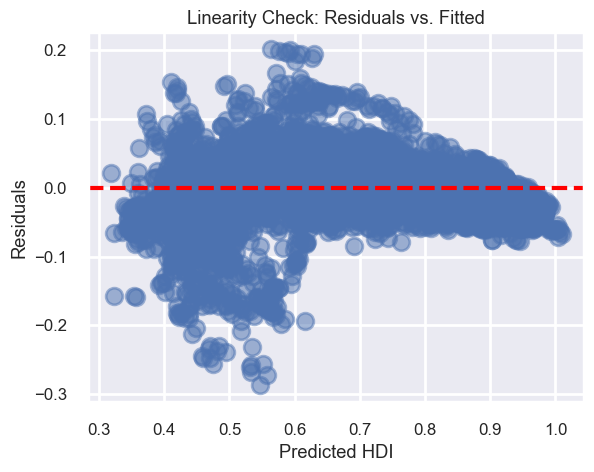

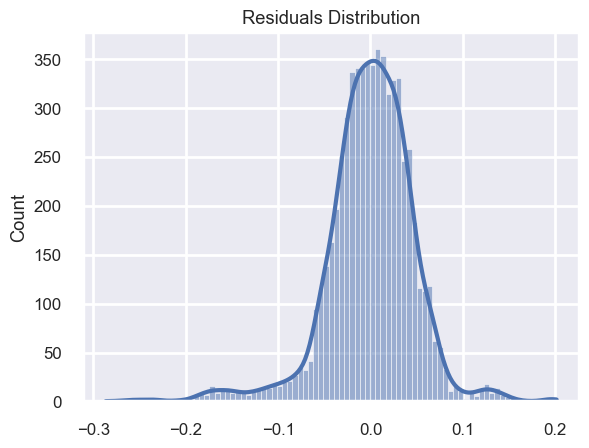

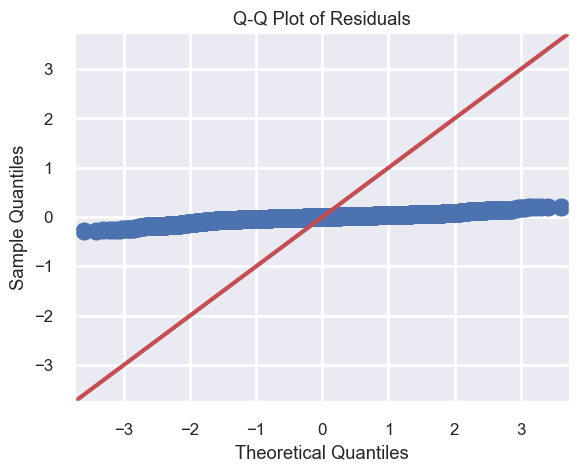

                      feature          VIF
0             life_expectancy  7118.507032
18    seats_in_parliament_m_%  2175.597347
5                life_expec_m  1831.681225
4                life_expec_f  1827.269547
10           gross_inc_percap   458.360475
2                       hdi_f   287.182464
12         gross_inc_percap_m   270.295692
3                       hdi_m   155.750686
17    seats_in_parliament_f_%   124.288762
15    secondary_education_f_%   109.682809
6            mean_yr_school_f   107.273889
16    secondary_education_m_%    88.398505
7            mean_yr_school_m    80.180135
13         gender_development    62.453474
11         gross_inc_percap_f    42.823831
8           expec_yr_school_f    23.296332
9           expec_yr_school_m    17.500971
21          co2_emission_tons     5.167997
14          gender_inequality     4.979486
22  mat_footprint_percap_tons     4.769155
19   labour_participation_f_%     1.545069
20   labour_participation_m_%     1.433814
1          

In [77]:
import matplotlib.pyplot as plt

#linearity check

# Predicted values
y_pred = ols_model.predict(X_const)

# Residuals
residuals = y - y_pred

# Plot
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted HDI')
plt.ylabel('Residuals')
plt.title('Linearity Check: Residuals vs. Fitted')
plt.show()

# Homoscedacticity Check
import statsmodels.stats.api as sms

bp_test = sms.het_breuschpagan(residuals, X_const)
bp_labels = ['Lagrange multiplier stat', 'p-value', 'f-value', 'f p-value']
dict(zip(bp_labels, bp_test))

#normality of residuals

import scipy.stats as stats
import seaborn as sns

# Histogram
sns.histplot(residuals, kde=True)
plt.title('Residuals Distribution')
plt.show()

# Q-Q plot
sm.qqplot(residuals, line='45')
plt.title('Q-Q Plot of Residuals')
plt.show()

# multicollinearity check

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data.sort_values('VIF', ascending=False))


# autoocrrelation check

from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(residuals)
print(f'Durbin-Watson: {dw:.3f}')



linearity assumption is not satisfied and VIF is too high for most of the variables. When we removel those variables the other variables VIF values increas to the unacceptable value. hence MLR is not good choice for the prediction.


SVR - Tuning and Training...
Best params: {'svr__C': 1, 'svr__gamma': 'scale', 'svr__kernel': 'rbf'}
Train RMSE: 0.0530, R²: 0.8979
Test RMSE: 0.0541, R²: 0.8934

RandomForest - Tuning and Training...
Best params: {'randomforest__max_depth': 15, 'randomforest__min_samples_split': 2, 'randomforest__n_estimators': 300}
Train RMSE: 0.0086, R²: 0.9973
Test RMSE: 0.0224, R²: 0.9817

XGBoost - Tuning and Training...
Best params: {'xgboost__learning_rate': 0.1, 'xgboost__max_depth': 5, 'xgboost__n_estimators': 300}
Train RMSE: 0.0066, R²: 0.9984
Test RMSE: 0.0182, R²: 0.9880

ANN - Tuning and Training...
Best params: {'ann__alpha': 0.01, 'ann__hidden_layer_sizes': (100, 50)}
Train RMSE: 0.0345, R²: 0.9567
Test RMSE: 0.0403, R²: 0.9407

📊 Model Comparison Summary:
                  Train RMSE  Test RMSE  Train R²   Test R²
XGBoost             0.006625   0.018169  0.998402  0.987957
RandomForest        0.008592   0.022410  0.997312  0.981678
ANN                 0.034501   0.040334  0.956658  0

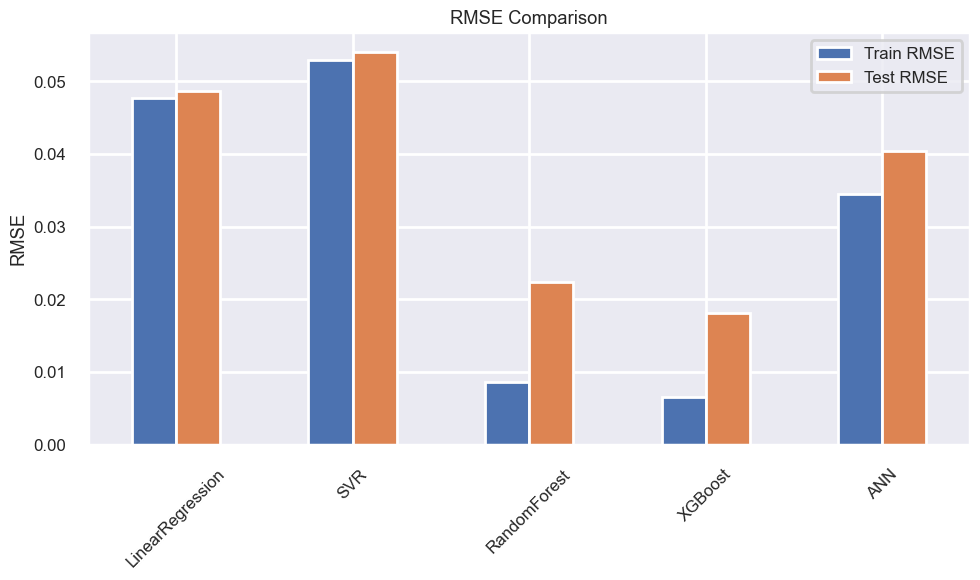

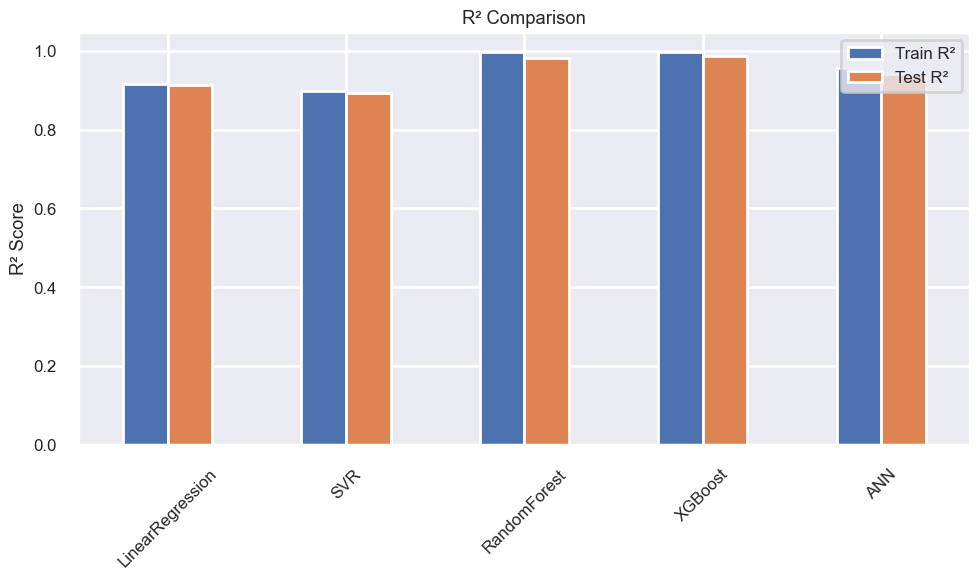


Best model: XGBoost


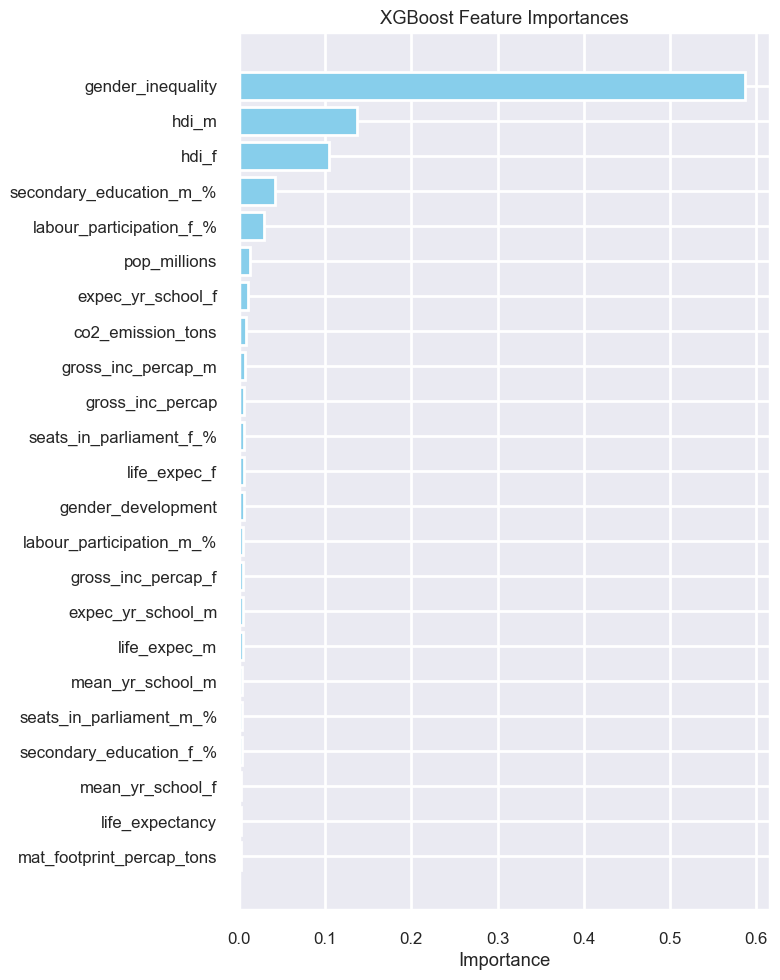

In [78]:
features = [
    'life_expectancy', 'pop_millions', 'hdi_f', 'hdi_m',
    'life_expec_f', 'life_expec_m', 'mean_yr_school_f',
    'mean_yr_school_m', 'expec_yr_school_f', 'expec_yr_school_m',
    'gross_inc_percap', 'gross_inc_percap_f', 'gross_inc_percap_m',
    'gender_development', 'gender_inequality',
    'secondary_education_f_%', 'secondary_education_m_%',
    'seats_in_parliament_f_%', 'seats_in_parliament_m_%',
    'labour_participation_f_%', 'labour_participation_m_%',
    'co2_emission_tons', 'mat_footprint_percap_tons'
]

models = {
    "SVR": (SVR(), {
        "svr__C": [0.1, 1, 10],
        "svr__gamma": ['scale', 'auto'],
        "svr__kernel": ['rbf']
    }),
    "RandomForest": (RandomForestRegressor(random_state=42, n_jobs=-1), {
        "randomforest__n_estimators": [100, 200, 300],
        "randomforest__max_depth": [5, 10, 15],
        "randomforest__min_samples_split": [2, 5]
    }),
    "XGBoost": (XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1), {
        "xgboost__n_estimators": [100, 200, 300],
        "xgboost__max_depth": [3, 5, 7],
        "xgboost__learning_rate": [0.05, 0.1]
    }),
    "ANN": (MLPRegressor(max_iter=2000, random_state=42), {
        "ann__hidden_layer_sizes": [(50,), (100,), (100, 50)],
        "ann__alpha": [0.0001, 0.001, 0.01]
    })
}

# --- Model Training and Evaluation ---
for name, (model, params) in models.items():
    print(f"\n{name} - Tuning and Training...")

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        (name.lower(), model)
    ])

    grid = GridSearchCV(pipe, params, cv=5, scoring='neg_root_mean_squared_error')
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    results[name] = {
        "model": best_model,
        "train_rmse": mean_squared_error(y_train, y_train_pred, squared=False),
        "test_rmse": mean_squared_error(y_test, y_test_pred, squared=False),
        "train_r2": r2_score(y_train, y_train_pred),
        "test_r2": r2_score(y_test, y_test_pred)
    }

    print(f"Best params: {grid.best_params_}")
    print(f"Train RMSE: {results[name]['train_rmse']:.4f}, R²: {results[name]['train_r2']:.4f}")
    print(f"Test RMSE: {results[name]['test_rmse']:.4f}, R²: {results[name]['test_r2']:.4f}")

# --- Model Comparison Summary ---
print("\n\U0001F4CA Model Comparison Summary:")
summary = pd.DataFrame({
    model: {
        "Train RMSE": res["train_rmse"],
        "Test RMSE": res["test_rmse"],
        "Train R²": res["train_r2"],
        "Test R²": res["test_r2"]
    }
    for model, res in results.items()
}).T

print(summary.sort_values("Test RMSE"))

# --- Performance Plots ---
summary[["Train RMSE", "Test RMSE"]].plot(kind='bar', figsize=(10, 6))
plt.title("RMSE Comparison")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

summary[["Train R²", "Test R²"]].plot(kind='bar', figsize=(10, 6))
plt.title("R² Comparison")
plt.ylabel("R² Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Feature Importance for Best Model ---
best_model_name = summary["Test RMSE"].idxmin()
best_pipe = results[best_model_name]["model"]
print(f"\nBest model: {best_model_name}")

if best_model_name in ["RandomForest", "XGBoost"]:
    importances = best_pipe.named_steps[best_model_name.lower()].feature_importances_
    feature_df = pd.DataFrame({"Feature": features, "Importance": importances})
    feature_df = feature_df.sort_values("Importance", ascending=True)
    plt.figure(figsize=(8, 10))
    plt.barh(feature_df["Feature"], feature_df["Importance"], color='skyblue')
    plt.xlabel("Importance")
    plt.title(f"{best_model_name} Feature Importances")
    plt.tight_layout()
    plt.show()
else:
    print("Feature importances are not available for this model type.")

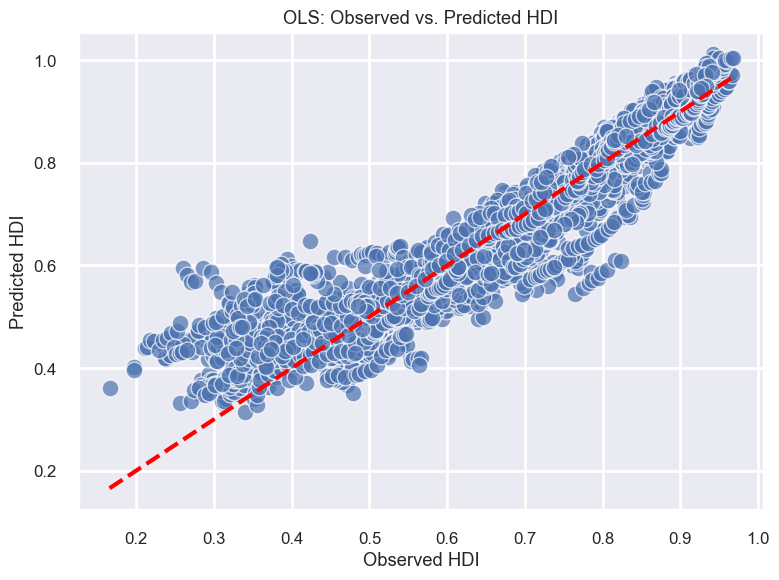

In [121]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_predict
import matplotlib.pyplot as plt
import seaborn as sns

ols_model = LinearRegression()
# Generate cross-validated predictions for OLS
y_pred_ols = cross_val_predict(ols_model, X, y, cv=5)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y, y=y_pred_ols, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
plt.xlabel("Observed HDI")
plt.ylabel("Predicted HDI")
plt.title("OLS: Observed vs. Predicted HDI")
plt.tight_layout()
plt.show()


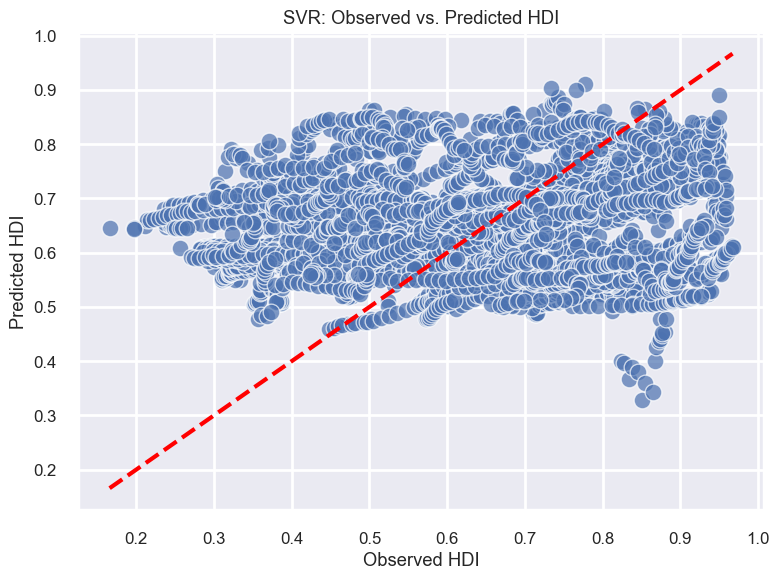

In [122]:
from sklearn.svm import SVR

svr_model = SVR(kernel='rbf', C=1, gamma='scale')
# Generate cross-validated predictions for SVR
y_pred_svr = cross_val_predict(svr_model, X, y, cv=5)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y, y=y_pred_svr, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
plt.xlabel("Observed HDI")
plt.ylabel("Predicted HDI")
plt.title("SVR: Observed vs. Predicted HDI")
plt.tight_layout()
plt.show()





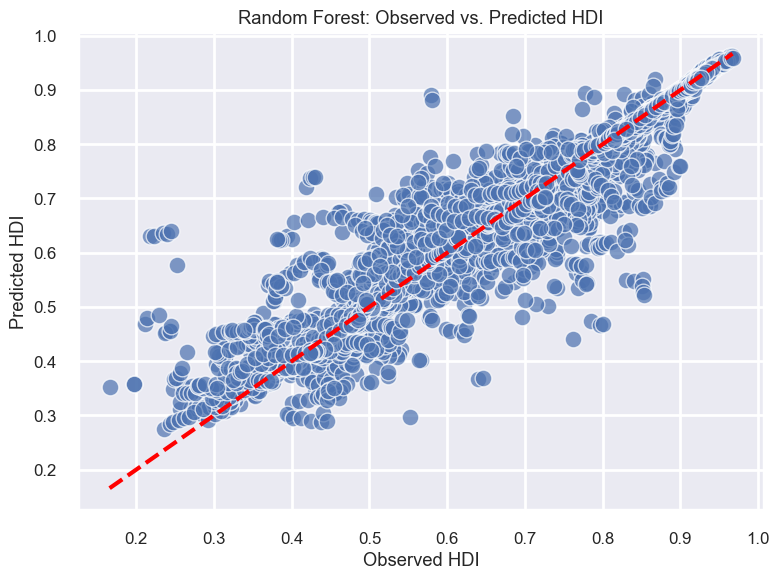

In [123]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42)
# Generate cross-validated predictions for Random Forest
y_pred_rf = cross_val_predict(rf_model, X, y, cv=5)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y, y=y_pred_rf, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
plt.xlabel("Observed HDI")
plt.ylabel("Predicted HDI")
plt.title("Random Forest: Observed vs. Predicted HDI")
plt.tight_layout()
plt.show()


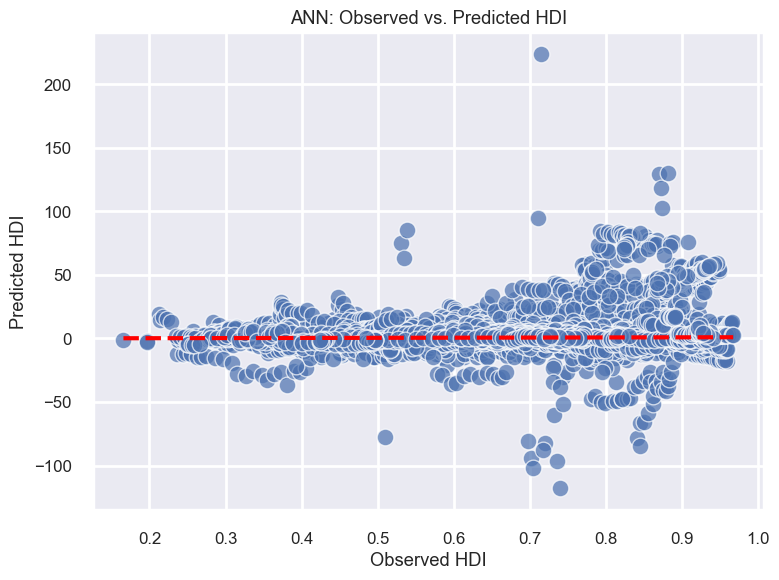

In [124]:
from sklearn.neural_network import MLPRegressor

ann_model = MLPRegressor(max_iter=2000, hidden_layer_sizes=(100, 50), random_state=42)
# Generate cross-validated predictions for ANN
y_pred_ann = cross_val_predict(ann_model, X, y, cv=5)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y, y=y_pred_ann, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
plt.xlabel("Observed HDI")
plt.ylabel("Predicted HDI")
plt.title("ANN: Observed vs. Predicted HDI")
plt.tight_layout()
plt.show()
